In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 34.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

# Визуализация

Воспользуемся датасетом с данными "retail_sales_mock_data.csv", содержащий временной ряд розничных продаж.

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/Andrey-V-Gorin/Gorin_A_V_MAI/refs/heads/main/Predictive_analytics/LW_1/retail_sales_mock_data.csv",
parse_dates=True, index_col="Date")
df.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


##Первичный анализ временного ряда:

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

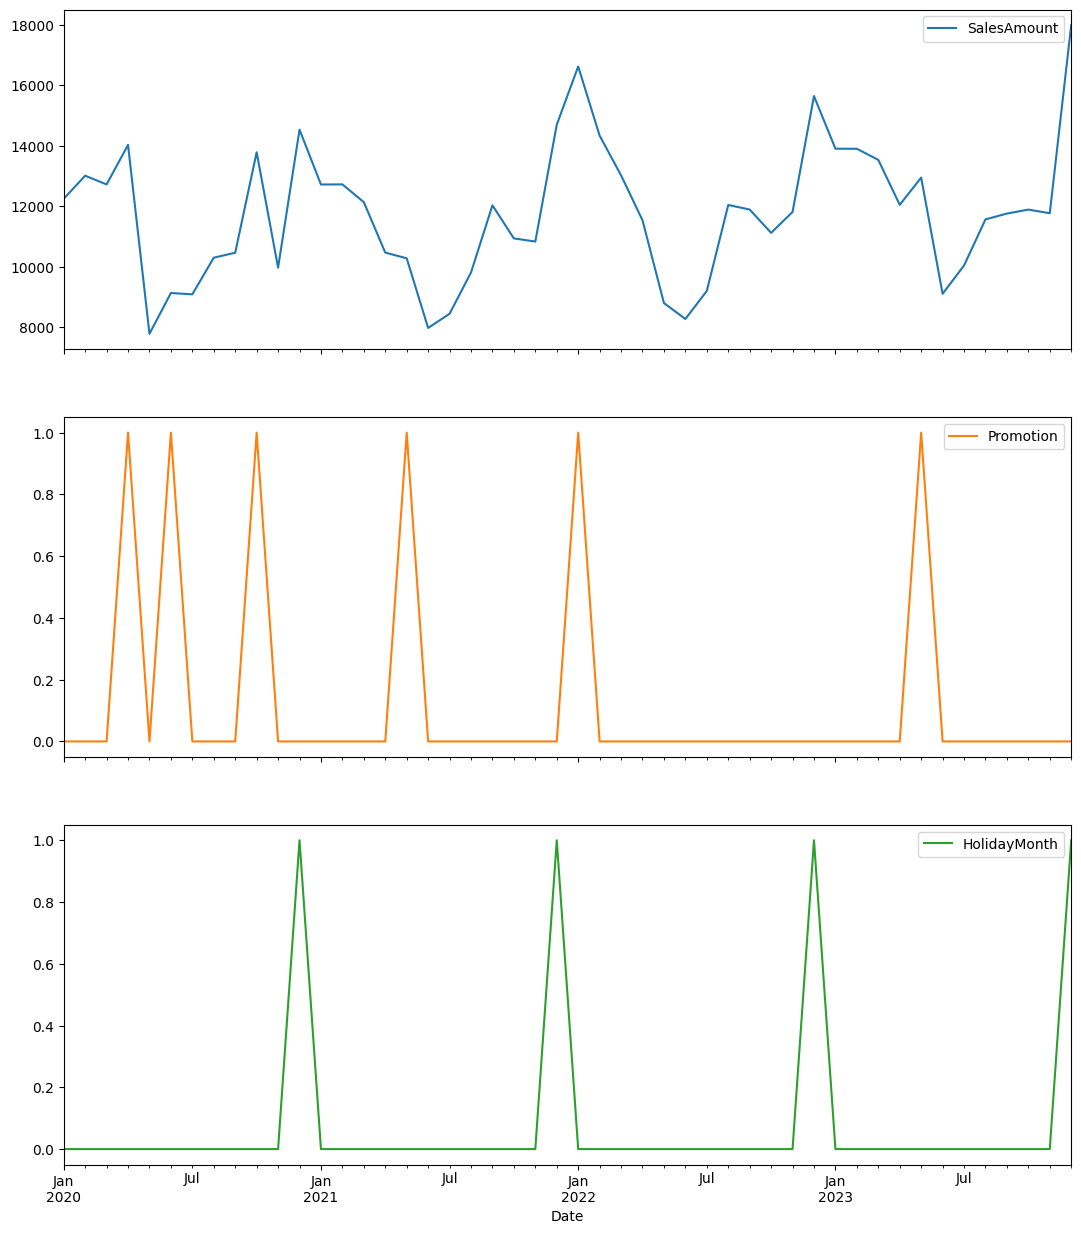

In [ ]:
df.plot(subplots=True, figsize=(13,15))

**Вывод:**

Графический анализ временного ряда продаж показывает наличие восходящего тренда, хотя и слабо выраженного. Значения показателя SalesAmount постепенно увеличиваются на протяжении рассматриваемого периода 2020–2023 гг., что свидетельствует о росте объема продаж компании.

Одновременно наблюдаются регулярные колебания показателя внутри каждого года, что указывает на возможное присутствие сезонной компоненты.

## Визуализация помесячно

[Text(0.5, 1.0, 'Выручка за месяц с начала 2020 по конец 2023 года'),
 Text(0.5, 0, 'Месяц'),
 Text(0, 0.5, 'Выручка')]

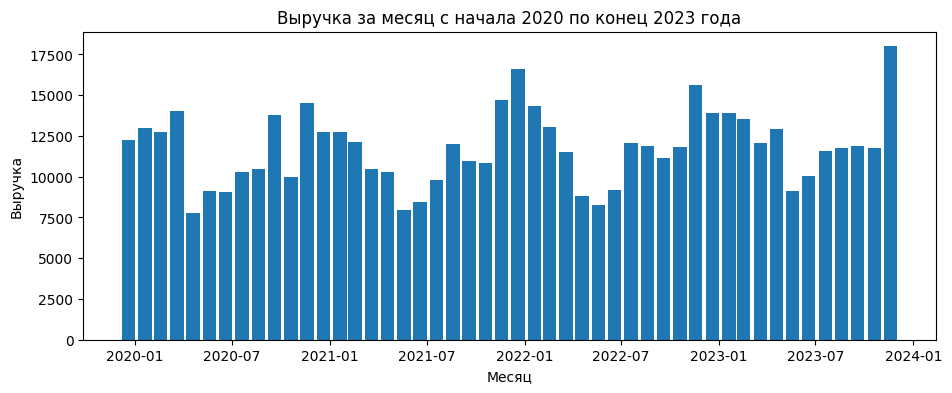

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m'))
ax.bar(df['2020':].index, df.loc['2020':, "SalesAmount"], width=-25, align='edge')
ax.set(title = 'Выручка за месяц с начала 2020 по конец 2023 года', xlabel = 'Месяц', ylabel = 'Выручка')

## Процентное соотношение

Вычисляется как отношение между текущим и предыдущим значением в процентном соотношение (нужно ещё домножить на сто). Пример того, как можно построить процентное изменение временных рядов в Python:

<BarContainer object of 48 artists>

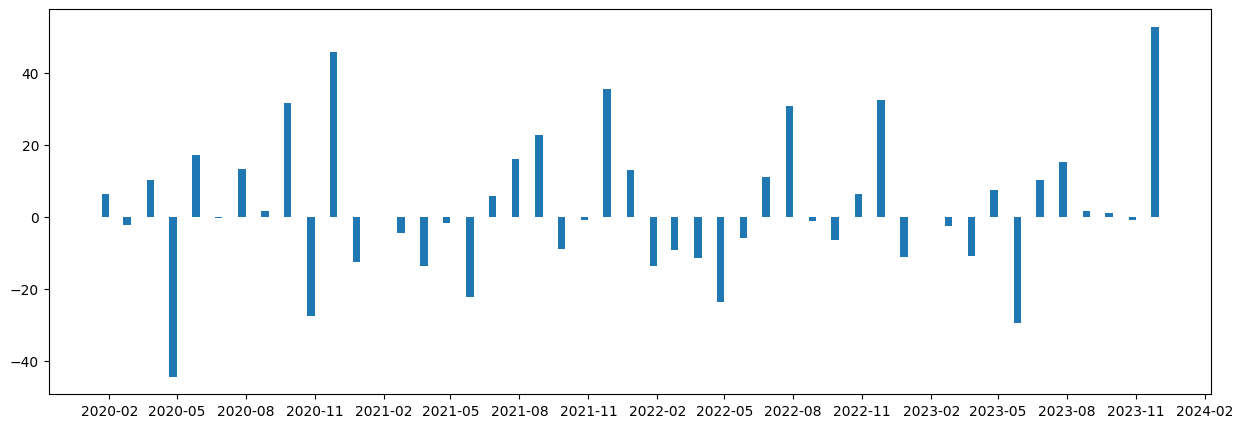

In [ ]:
import matplotlib.dates as mdates

df.loc[:, 'pct_change'] = df.SalesAmount.pct_change() * 100

fig, ax = plt.subplots(figsize=(15, 5))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.bar(df.index, df.loc[:, 'pct_change'], width=-10, align='edge')

**Вывод:**

Анализ темпов изменения продаж (pct_change) позволяет выявить периоды наиболее сильного роста и падения выручки.

Полученные результаты показывают, что:

	•	изменения продаж имеют значительную волатильность;
	•	наблюдаются периоды резкого роста, совпадающие с активными продажами;
	•	отрицательные значения отражают сезонные или краткосрочные снижения спроса.
  
Таким образом	значительные колебания (например, от +5% до -5%), могут указывать на риски или нестабильность на рынке.

## Диаграмма размаха

<Axes: xlabel='Month', ylabel='SalesAmount'>

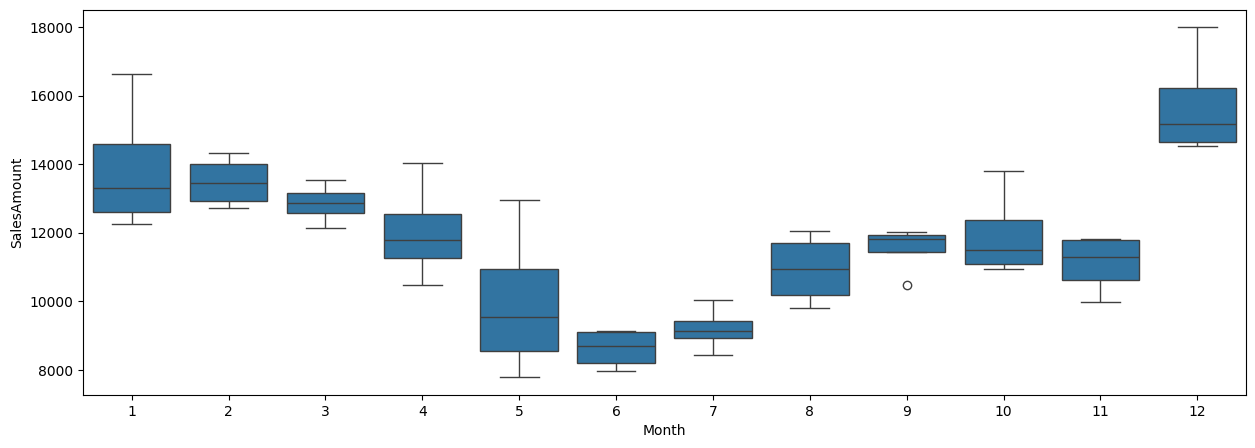

In [ ]:
import seaborn as sns

df['Month'] = df.index.month
fig, axes = plt.subplots(figsize=(15, 5), sharex=True)
sns.boxplot(df, x='Month', y='SalesAmount', ax=axes)

**Вывод:**

Диаграма размаха распределения продаж по месяцам показывает существенную неоднородность распределения значений в разные периоды года.

Полученные результаты свидетельствуют о наличии выраженной сезонности: в одни месяцы продажи стабильно выше медианных значений, в другие — ниже.

Это подтверждает предположение о существовании годового сезонного цикла.

Text(0.5, 1.0, 'SalesAmount 2022-2023')

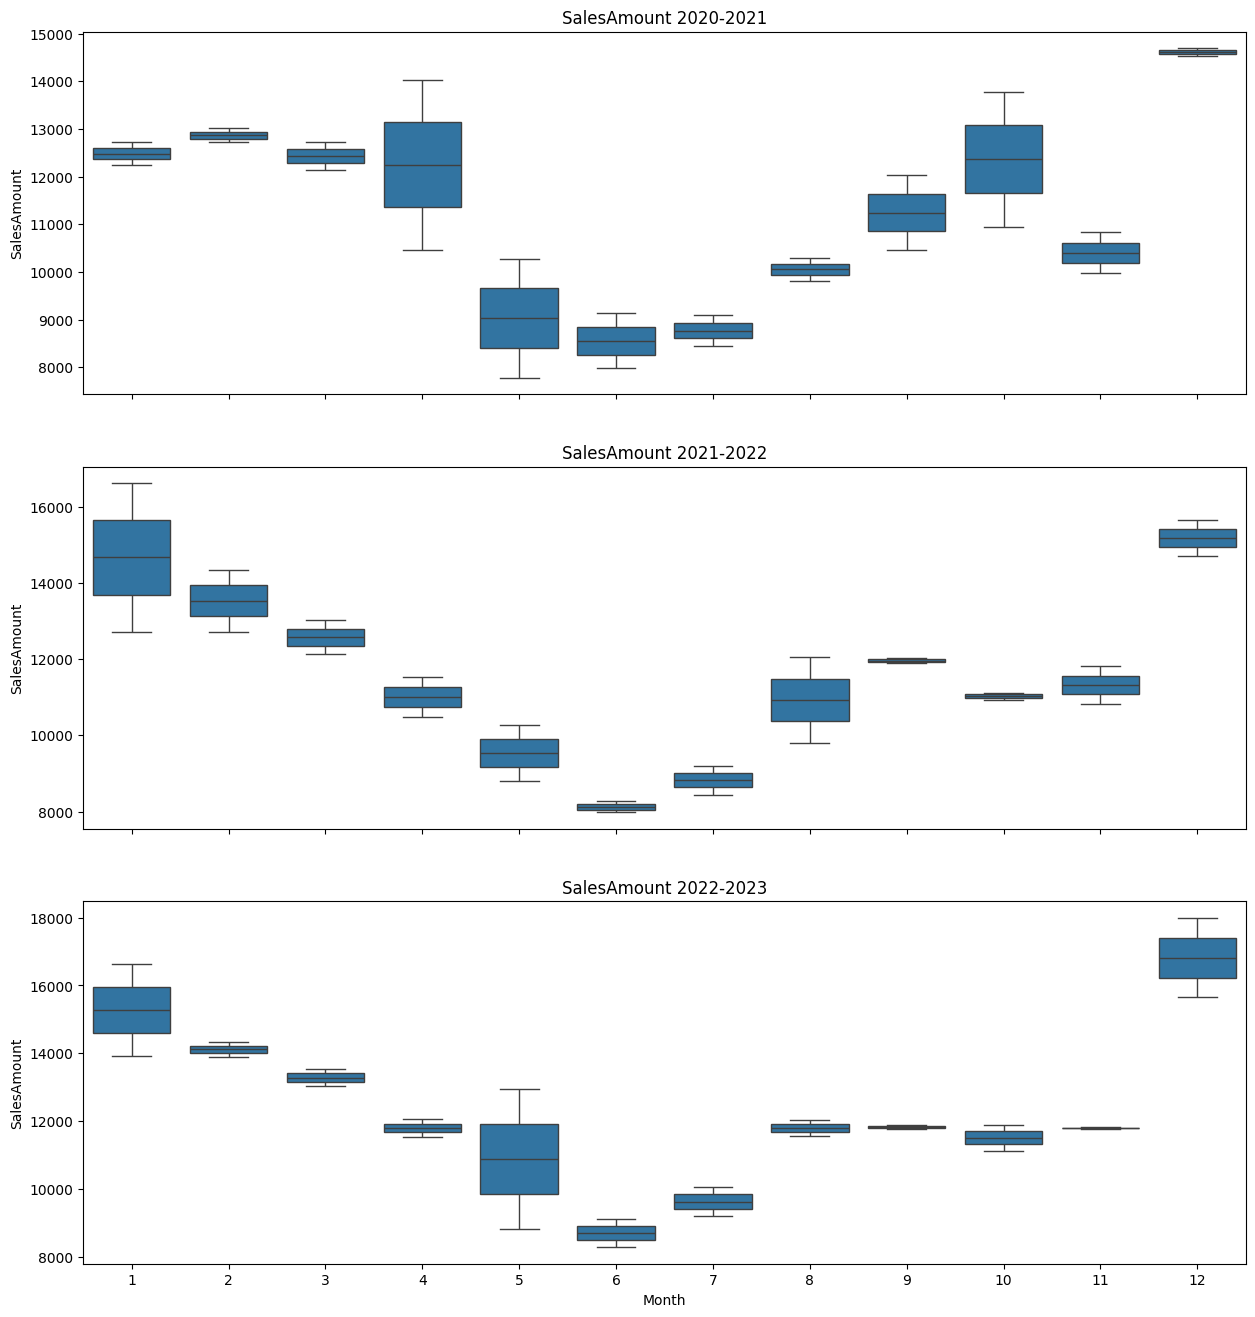

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 16), sharex=True)

sns.boxplot(data=df['2020':'2021'], x='Month', y='SalesAmount', ax=axes[0])
axes[0].set_title("SalesAmount 2020-2021")

sns.boxplot(data=df['2021':'2022'], x='Month', y='SalesAmount', ax=axes[1])
axes[1].set_title("SalesAmount 2021-2022")

sns.boxplot(data=df['2022':'2023'], x='Month', y='SalesAmount', ax=axes[2])
axes[2].set_title("SalesAmount 2022-2023")

**Вывод:**

Сравнение распределений продаж по месяцам для разных годов показывает, что структура сезонных колебаний сохраняется во времени.

Это означает, что сезонная компонента является устойчивой и повторяющейся, что характерно для большинства торговых временных рядов.


## Разное время, один график

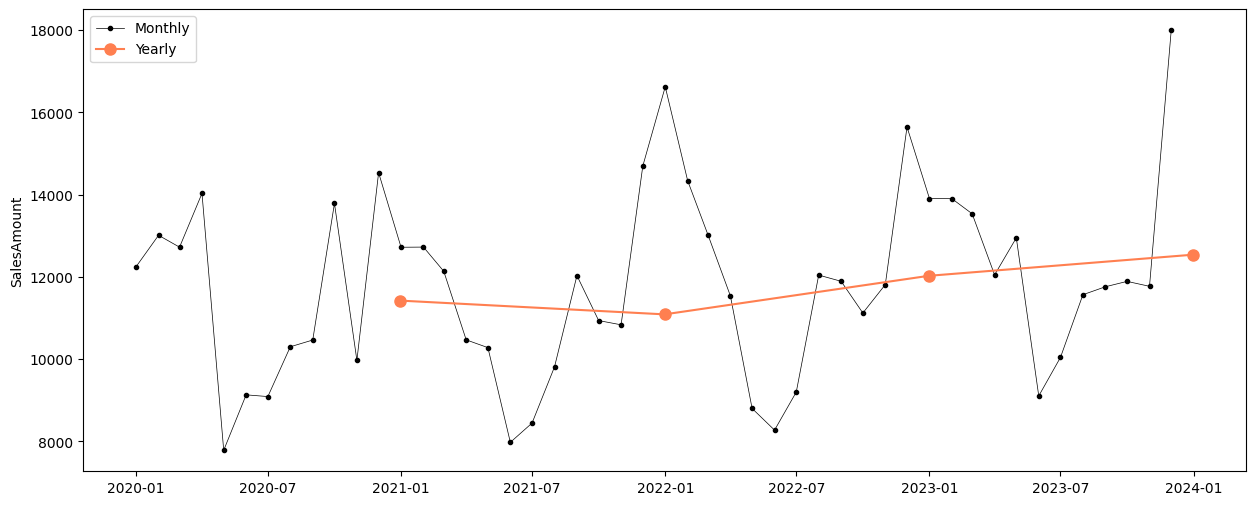

In [ ]:
df_year = df.resample("YE").mean()
start, end = pd.to_datetime('2020-01-01', format='%Y-%m-%d'), pd.to_datetime('2024-01-01', format='%Y-%m-%d')
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df.loc[start:end, 'SalesAmount'], marker='.', linestyle='-', linewidth = 0.5, label='Monthly', color='black')
ax.plot(df_year.loc[start:end, 'SalesAmount'], marker='o', markersize=8, linestyle='-', label='Yearly', color='coral')
ax.set_ylabel("SalesAmount")
ax.legend()

## Тепловые карты

В рамках визуализации временных рядов полезными являются тепловые карты (heatmap). Для начала на основе наших данных построим таблицу зависимости цены открытия в заданном году и месяце. Для этого воспользуемся функцией pivot_table. А чтобы отображать месяцы в виде аббревиатур, а не чисел, используется стандартный Python-модуль calendar.

In [ ]:
import calendar

df['month'] = df.index.month
df['year'] = df.index.year

all_month_year_df = pd.pivot_table(df, values="SalesAmount",
                                   index=["month"],
                                   columns=["year"],
                                   fill_value=0)
month_index = [month for month in calendar.month_abbr if month]

all_month_year_df = all_month_year_df.set_index([month_index])
all_month_year_df

year,2020,2021,2022,2023
Jan,12248.0,12720.0,16623.0,13904.0
Feb,13011.0,12724.0,14336.0,13901.0
Mar,12722.0,12136.0,13023.0,13534.0
Apr,14030.0,10468.0,11537.0,12048.0
May,7783.0,10279.0,8800.0,12949.0
Jun,9131.0,7976.0,8273.0,9104.0
Jul,9089.0,8445.0,9199.0,10042.0
Aug,10300.0,9810.0,12043.0,11566.0
Sep,10464.0,12031.0,11892.0,11759.0
Oct,13786.0,10937.0,11121.0,11890.0


Text(0.5, 1.0, 'Выручка по месяцам')

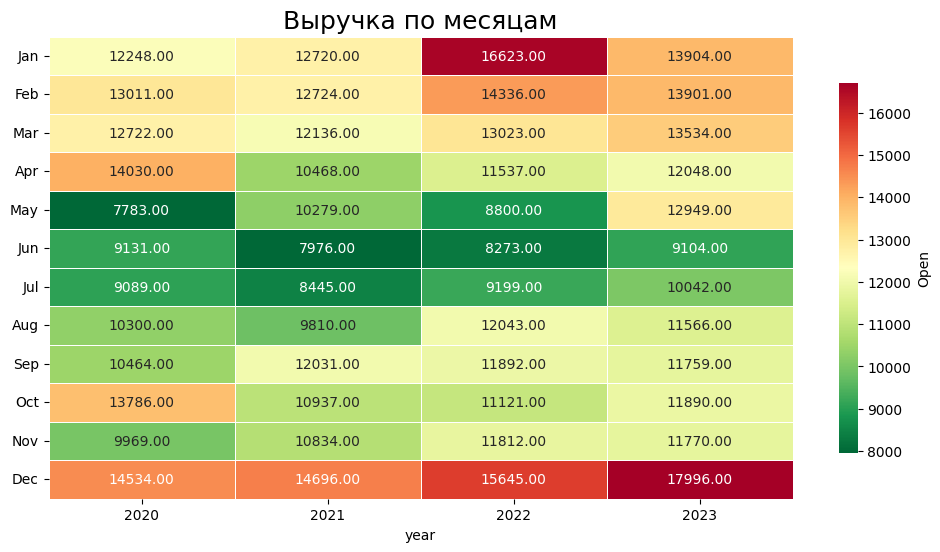

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(12,6))
ax = sns.heatmap(all_month_year_df, cmap='RdYlGn_r', robust=True,
                 fmt='.2f', annot=True, linewidths=.5, ax=ax,
                 cbar_kws={'shrink':.8, 'label':'Open'})

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.title('Выручка по месяцам', fontdict={'fontsize':18})

**Вывод:**

Тепловая карта распределения продаж по месяцам и годам позволяет наглядно выявить периоды максимальных и минимальных значений показателя.

Анализ показывает:

	•	наличие повторяющихся периодов повышенных продаж;
	•	схожую структуру распределения продаж по месяцам в разные годы;
	•	устойчивую сезонную структуру временного ряда.


## Скользящее среднее

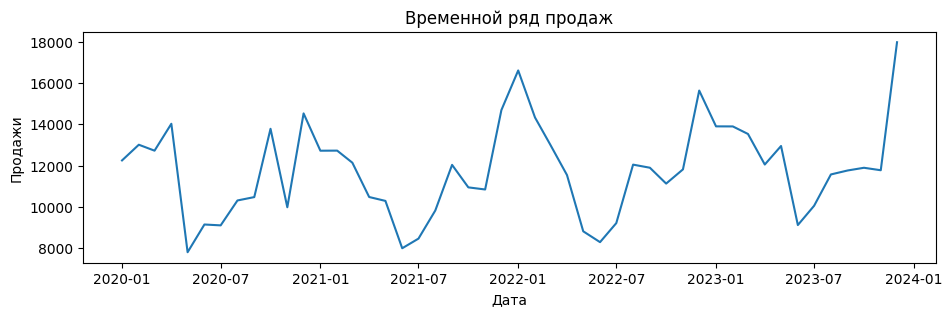

In [ ]:
plt.figure(figsize=(11,3))
plt.plot(df['SalesAmount'])
plt.title("Временной ряд продаж")
plt.xlabel("Дата")
plt.ylabel("Продажи")
plt.show()

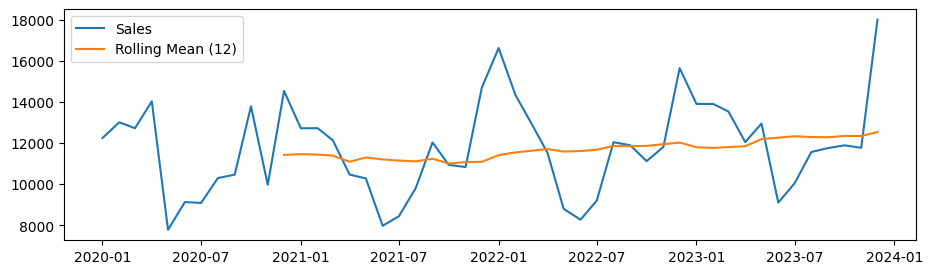

In [ ]:
df['rolling_mean'] = df['SalesAmount'].rolling(12).mean()

plt.figure(figsize=(11,3))
plt.plot(df['SalesAmount'], label='Sales')
plt.plot(df['rolling_mean'], label='Rolling Mean (12)')
plt.legend()
plt.show()

**Вывод:**

Скользящее среднее используется для сглаживания краткосрочных колебаний временного ряда.

График показывает, что после сглаживания более отчетливо проявляется долгосрочный тренд роста продаж, что подтверждает наличие трендовой компоненты в структуре временного ряда.

## Автокорреляционный анализ (ACF) и Частичная автокорреляция (PACF)

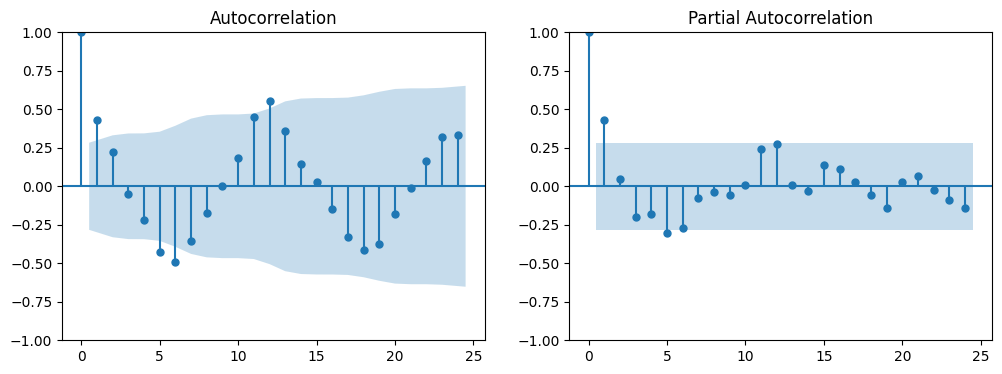

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1,2, figsize=(12,4))

plot_acf(df['SalesAmount'], lags=24, ax=ax[0])
plot_pacf(df['SalesAmount'], lags=24, ax=ax[1])

plt.show()

**Автокорреляционный анализ (ACF)**

Автокорреляционная функция демонстрирует наличие значимых корреляций между текущими значениями временного ряда и его лагами.

Значимые пики автокорреляции на определенных лагах свидетельствуют о наличии сезонных зависимостей и инерционности временного ряда.

**Частичная автокорреляция (PACF)**

Частичная автокорреляционная функция позволяет выявить прямые зависимости между наблюдениями временного ряда без влияния промежуточных лагов.

Полученные результаты могут быть использованы для определения порядка авторегрессионной части моделей типа ARIMA.

## Проверка стационарности (ADF)

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['SalesAmount'])

print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -4.5141835977339575
p-value: 0.00018535586430261453


**Интерпретация:**

Нулевая гипотеза теста Дики–Фуллера предполагает наличие единичного корня, то есть нестационарность временного ряда.

Так как

p\text{-value} = 0.000185 < 0.05

нулевая гипотеза отвергается.

**Вывод:**

Временной ряд SalesAmount является стационарным на уровне значимости 5%. Это означает, что статистические характеристики ряда (среднее значение и дисперсия) не изменяются существенно во времени.

##Корреляционная матрица

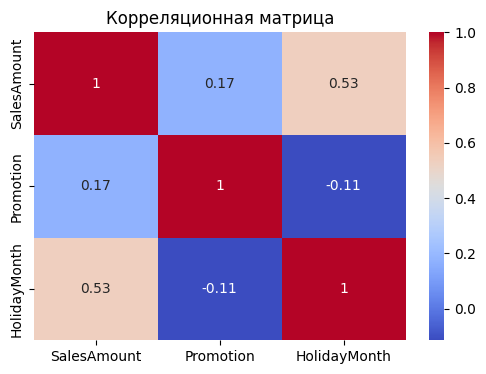

In [ ]:
corr = df[['SalesAmount','Promotion','HolidayMonth']].corr()
corr

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()

**Вывод:**

Корреляционный анализ исследует связь между:

	•	SalesAmount
	•	Promotion
	•	HolidayMonth

Интерпретация результатов:

	•	переменная Promotion показывает положительную корреляцию с продажами, что указывает на эффективность маркетинговых мероприятий;
	•	переменная HolidayMonth также оказывает влияние на продажи, отражая сезонный рост спроса в праздничные периоды.

Таким образом, маркетинговые акции и праздничные периоды являются значимыми факторами, влияющими на динамику продаж.

# Модели декомпозиции на компоненты

## Аддитивная
При аддитивной декомпозиции временной ряд выражается как сумма его составляющих: тренда, сезонности и остатка (шума). Математически это выглядит так:

$$y(t) = \text{Тренд}(t) + \text{Сезонность}(t) + \text{Остаток}(t)$$

📊 Открываю стандартный график декомпозиции...


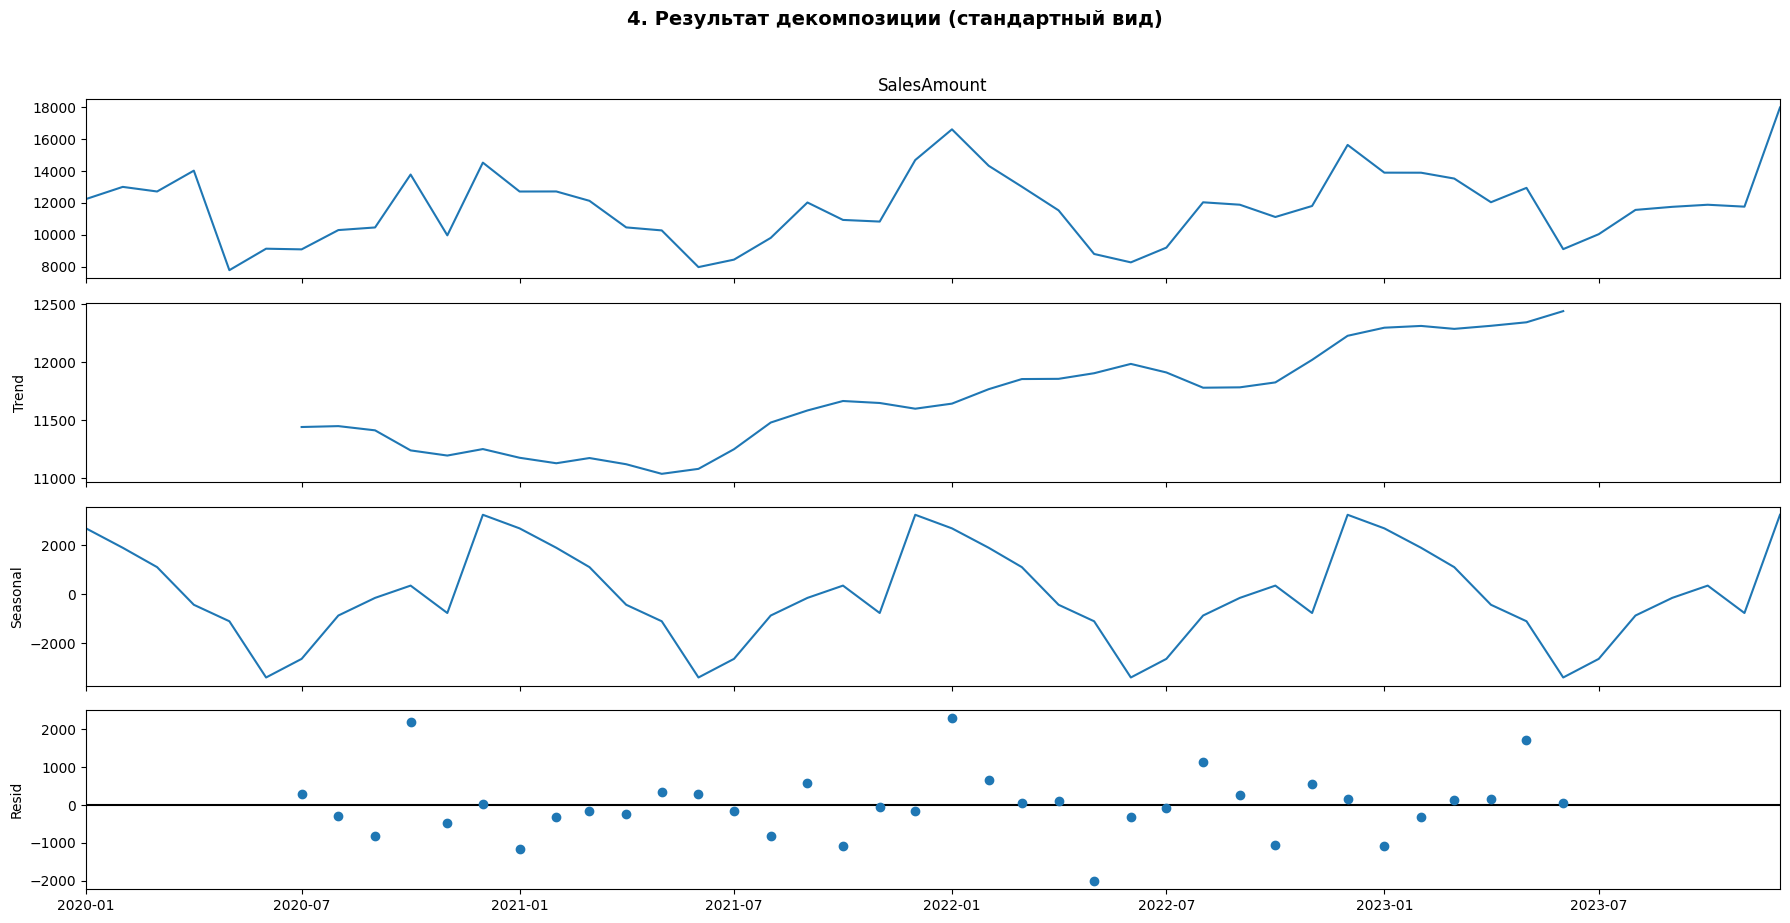

In [ ]:
# === ДЕКОМПОЗИЦИЯ ===
from statsmodels.tsa.seasonal import seasonal_decompose
'''
period - это длина одного сезонного цикла в ваших данных:
для месячных данных = 12 (год)
для квартальных = 4
для недельных = 52
для дневных = 7 или 365
'''

result = seasonal_decompose(df['SalesAmount'], model='additive', period=12)

# === ГРАФИК 4: Стандартная визуализация ===
print("📊 Открываю стандартный график декомпозиции...")
fig2 = result.plot()
# Делаем каждый подграфик шире
for ax in fig2.axes:
    ax.figure.set_size_inches(18, 9)  # ← ширина 18
plt.suptitle('4. Результат декомпозиции (стандартный вид)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Мультипликативная

При мультипликативном разложении компоненты перемножаются между собой:

$$y(t) = \text{Тренд}(t) \times \text{Сезонность}(t) \times \text{Остаток}(t)$$

Выбор между аддитивной и мультипликативной декомпозицией зависит от характера данных.
- Аддитивная декомпозиция подходит, когда величина сезонности остается относительно постоянной во времени.

- Мультипликативная декомпозиция уместна, когда сезонность растет или уменьшается пропорционально тренду.

📊 Открываю стандартный график декомпозиции...


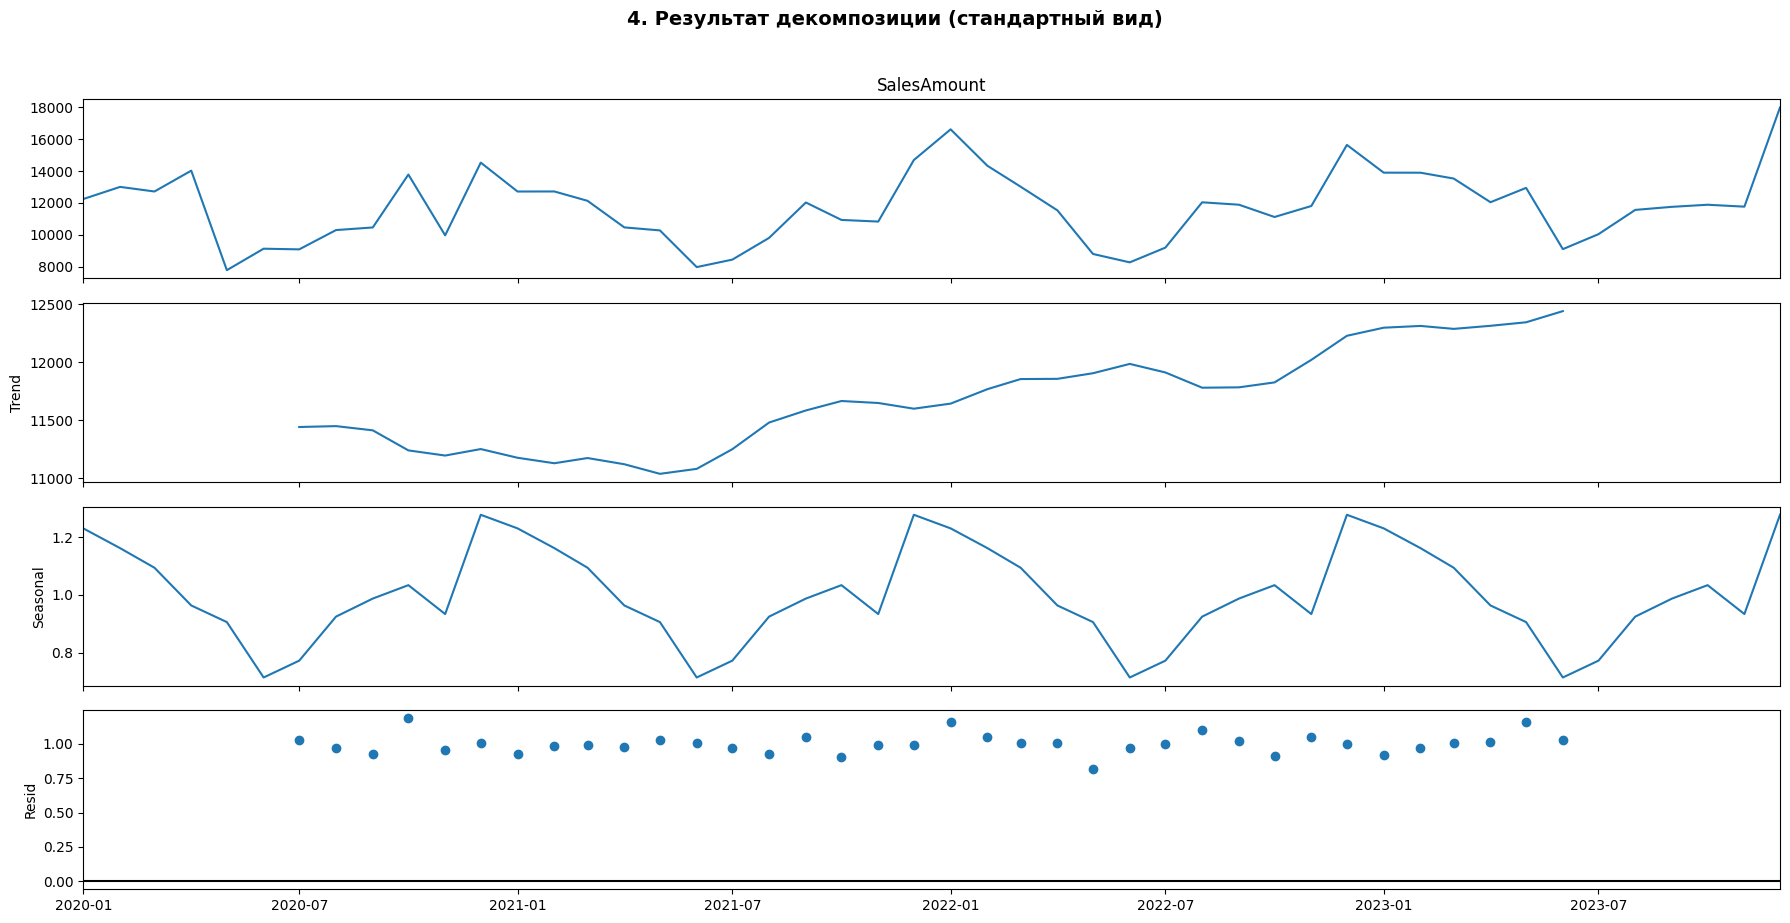

In [ ]:
# === ДЕКОМПОЗИЦИЯ ===

result = seasonal_decompose(df['SalesAmount'], model='multiplicative', period=12)

# === ГРАФИК 4: Стандартная визуализация ===
print("📊 Открываю стандартный график декомпозиции...")
fig2 = result.plot()
# Делаем каждый подграфик шире
for ax in fig2.axes:
    ax.figure.set_size_inches(18, 9)  # ← ширина 18
plt.suptitle('4. Результат декомпозиции (стандартный вид)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Вывод:**

Декомпозиция временного ряда позволяет представить его как сумму нескольких компонент:

	•	тренд
	•	сезонность
	•	остаточная случайная компонента

Результаты декомпозиции подтверждают наличие устойчивой сезонной структуры и долгосрочного тренда роста продаж.

## STL декомпозиция

В отличие от классической декомпозиции, STL позволяет сезонности меняться со временем.

Использует LOESS – взвешенную линейную регрессию для сглаживания тренда и сезонности.

Идея LOESS: для каждой точки строится своя линейная регрессия только по ближайшим соседям. Чем ближе точка — тем больше её вес.

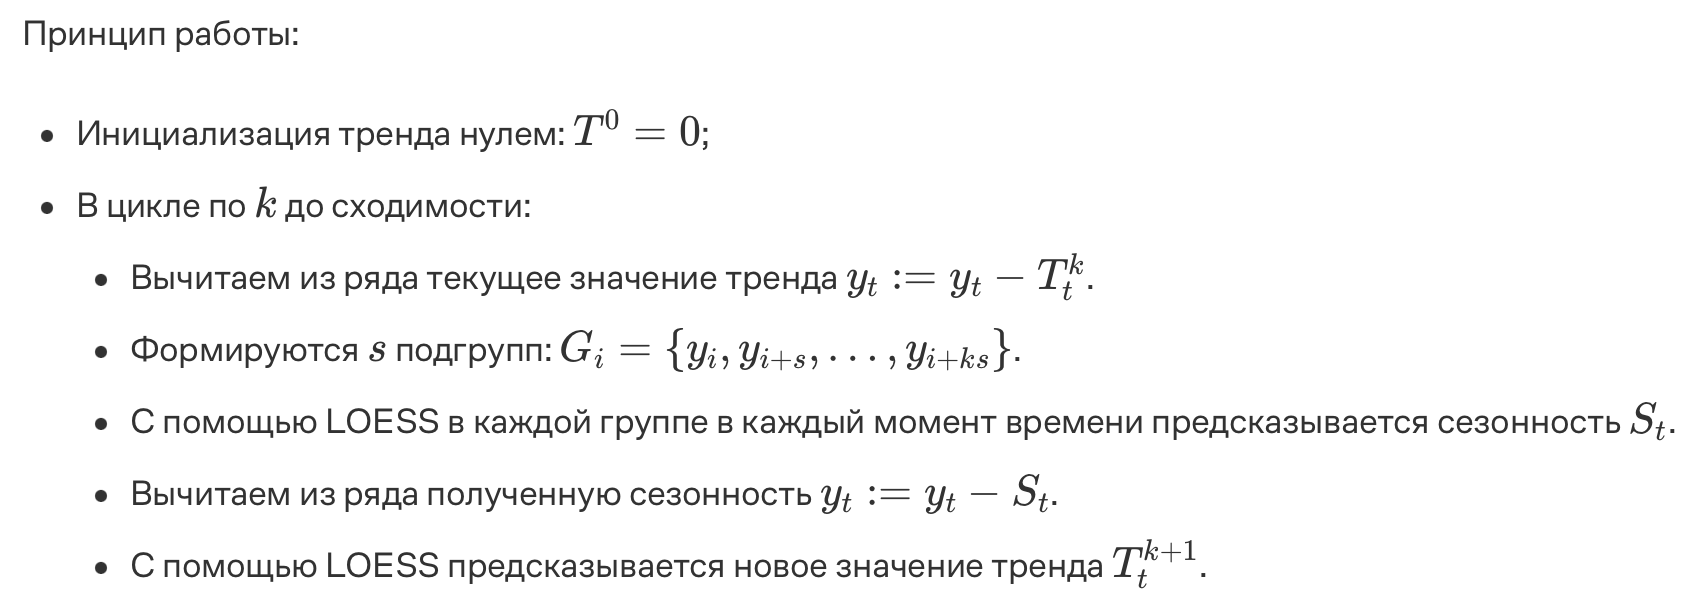

Шумовой компонент рассчитывается из остатка тренда и сезонности.
## Ключевые особенности STL-декомпозиции:
- Устойчивость к выбросам при robust=True
- Хорошо работает как с аддитивными, так и с мультипликативными временными рядами.

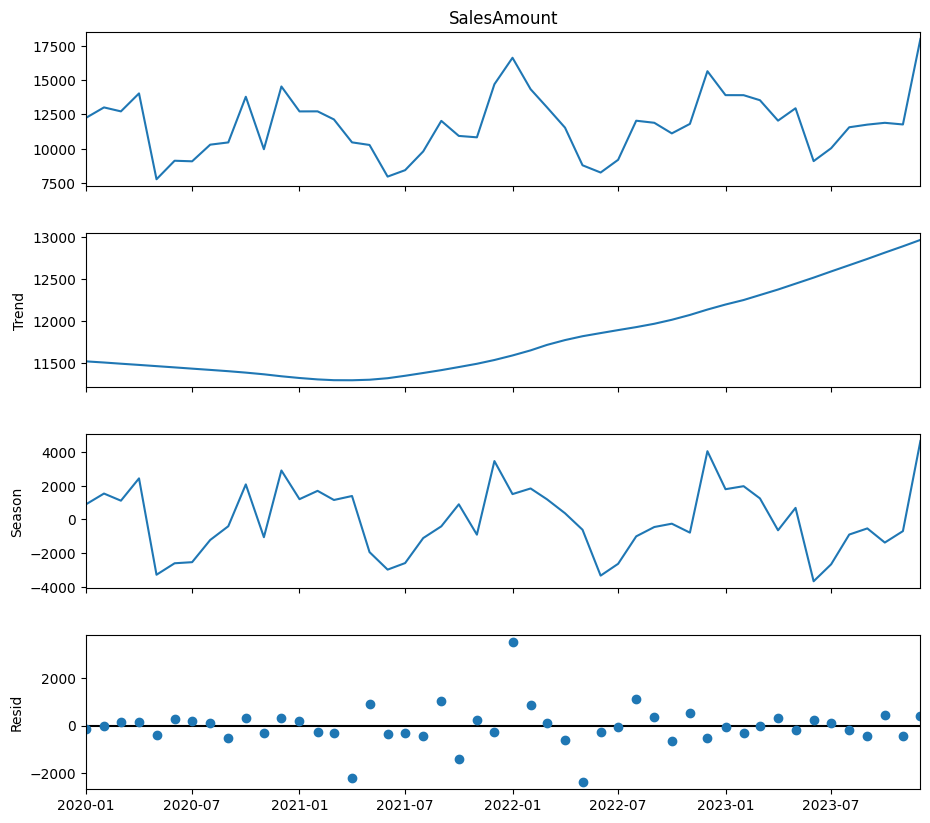

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

'''
seasonal - это размер окна сглаживания для сезонной составляющей.

Должен быть нечетным числом и обычно берется как period + 1
минимум должен быть >= 7
большие значения дают более гладкую сезонную составляющую
меньшие значения позволяют сезонности быстрее меняться во времени
'''

# Выполнение STL-декомпозиции
stl = STL(df['SalesAmount'],
          period=12,
          seasonal=13,
          robust=True)
result = stl.fit()


fig = result.plot()
fig.set_size_inches((10, 9))
plt.show()

**Вывод:**

STL-декомпозиция позволяет более гибко выделять сезонную компоненту, особенно в случаях, когда ее структура может изменяться во времени.

Полученные результаты показывают устойчивую сезонность и наличие постепенного тренда.

# Фурье-анализ (FFT)
Это разложение временного ряда на синусоиды разных частот.

Идея: Любой сложный сигнал можно представить как сумму простых волн (синусов и косинусов).

Ряд = Σ (амплитуда × sin(частота × t + фаза))

**Когда использовать Фурье-анализ?**
- Поиск скрытых периодичностей преположительно стабильных во времени
- Анализ циклов (экономика, астрономия)
- Фильтрация шума (низкочастотные фильтры)
- Сжатие сигналов

**Когда нельзя использовать**
- Нестационарные ряды (тренд, меняющаяся сезонность)
- Длинные пропуски
- Когда нужна интерпретация для бизнес-задач

Если вы подозреваете, что периодичность не постоянна (например, недельный паттерн сильнее зимой), используйте скользящее окно FFT

In [ ]:
# Убираем тренд (Фурье плохо работает с нестационарными рядами)

import numpy as np
from scipy.fft import fft, fftfreq
from scipy.signal import detrend

sales_detrended = detrend(df['SalesAmount'].values, type='linear')

In [ ]:
# Применяем FFT
# Параметры
dt = 1  # шаг времени = 1 месяц
n = len(sales_detrended)

# FFT
fft_vals = fft(sales_detrended)
freqs = fftfreq(n, dt)  # частоты в циклах/месяц

# Берём только положительные частоты
power = np.abs(fft_vals[:n//2])
freqs_pos = freqs[:n//2]

# Переводим частоту в период (месяцы)
periods = 1 / freqs_pos[freqs_pos > 0]
power_pos = power[freqs_pos > 0]

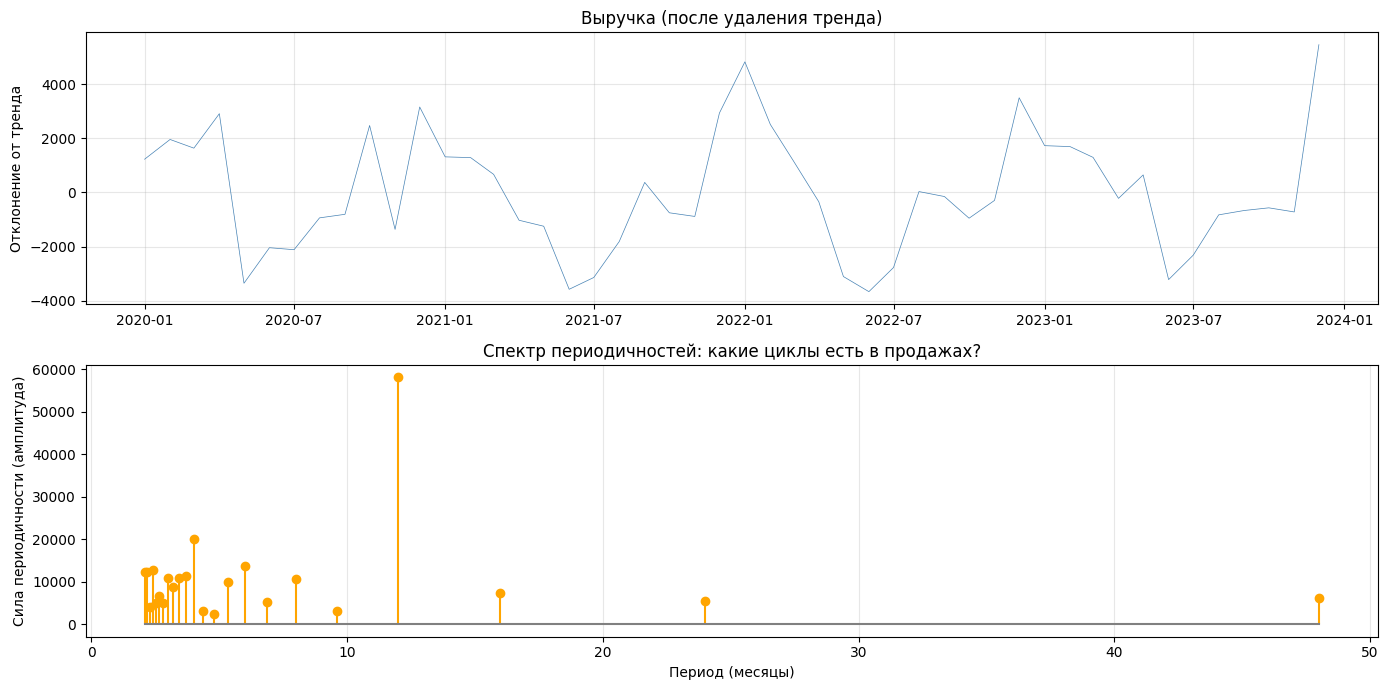

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(14, 7))

# Исходный ряд (после детрендинга)
axs[0].plot(df.index, sales_detrended, color='steelblue', linewidth=0.5)
axs[0].set_title('Выручка (после удаления тренда)')
axs[0].set_ylabel('Отклонение от тренда')
axs[0].grid(True, alpha=0.3)

# Спектр по периодам (удобнее для бизнеса)
mask = (periods >= 2) & (periods <= 48)  # показываем периоды от 2 до 48 месяца
axs[1].stem(periods[mask], power_pos[mask], linefmt='orange', markerfmt='o', basefmt='gray')
axs[1].set_xlabel('Период (месяцы)')
axs[1].set_ylabel('Сила периодичности (амплитуда)')
axs[1].set_title('Спектр периодичностей: какие циклы есть в продажах?')
axs[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [ ]:
# ИЗВЛЕЧЕНИЕ ВАЖНЫХ ЦИКЛОВ

def find_significant_periods(periods, power, threshold_factor=2.0, max_periods=5):
    """
    Находит значимые периодичности в спектре
    """
    # Порог: в 2 раза выше среднего (можно настроить)
    threshold = power.mean() * threshold_factor

    # Находим пики выше порога
    significant = power > threshold

    # Сортируем по силе и берём топ-N
    top_idx = np.where(significant)[0]
    top_idx = top_idx[np.argsort(power[top_idx])[::-1][:max_periods]]

    results = []
    for idx in top_idx:
        results.append({
            'period_months': periods[idx],
            'power': power[idx],
            'frequency': 1/periods[idx],
            'interpretation': interpret_period(periods[idx])
        })

    return results

def interpret_period(period):
    """Бизнес-интерпретация периода"""
    if 2 <= period <= 4:
        return "Квартальный цикл (Сезонность, промо)"
    elif 6.5 <= period <= 7.5:
        return "Полугодовой цикл (Пик в зима/лето)"
    elif 11 <= period <= 13:
        return "Годовой цикл (Новогодние праздники)"
    elif 23 <= period <= 25:
        return "Двхугодичный цикл"
    else:
        return f"Цикл ~{period:.0f} дней (требует анализа)"

# Запускаем анализ
cycles = find_significant_periods(periods, power_pos)

print("\n🔍 Найденные значимые циклы:")
print(f"{'Период':<12} {'Сила':<15} {'Интерпретация'}")
print("-" * 70)
for c in cycles:
    print(f"{c['period_months']:<12.1f} {c['power']:<15.2f} {c['interpretation']}")


🔍 Найденные значимые циклы:
Период       Сила            Интерпретация
----------------------------------------------------------------------
12.0         58111.28        Годовой цикл (Новогодние праздники)


Быстрое преобразование Фурье позволяет выявить скрытые циклические компоненты временного ряда.

Спектральный анализ показывает наличие доминирующих периодов колебаний, что подтверждает наличие регулярных циклов в динамике продаж.

# Вейвлет-преобразование (Wavelet Transform)

Похоже на фурье анализ, но говорит когда именно возникают частоты и их эволюцию во времени

Фурье-анализ:     «В данных есть период 7 дней» (но не говорит, когда)

Вейвлеты:         «Период 7 дней был сильным в январе, но исчез в марте»

Идея вейвлетов:

1.   Берём маленькую типовую «волну» (вейвлет) — короткий всплеск
2.   Прикладываем её к разным участкам ряда
3. Смотрим, насколько похоже (корреляция)
4. Меняем масштаб вейвлета (растягиваем/сжимаем) = меняем частоту
5. Повторяем для всех позиций и масштабов

Медленно вычисляется

/tmp/ipykernel_454/4257814012.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.0)


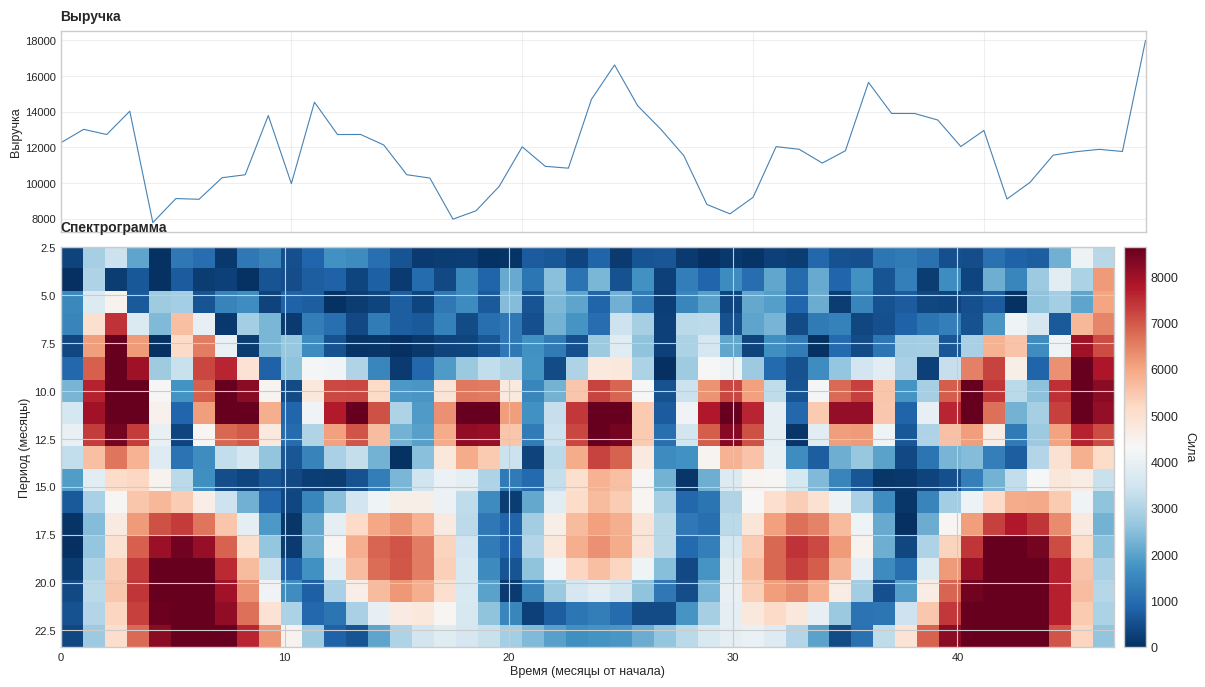

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Настройки оформления
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 9
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 9

# === Подготовка данных ===
signal = df['SalesAmount'].values

if df.index.dtype == 'datetime64[ns]':
    t = np.arange(len(signal))
    sampling_period = 1
else:
    t = np.arange(len(signal))
    sampling_period = 1

# === Вейвлет-преобразование ===
wavelet = 'morl'
scales = np.arange(1, 24)
coefficients, frequencies = pywt.cwt(signal, scales, wavelet, sampling_period=sampling_period)

# Подготовка спектрограммы
mask = frequencies > 0
periods = 1 / frequencies[mask]
coefficients_abs = np.abs(coefficients[mask, :])
period_mask = (periods >= 2) & (periods <= 24)
periods_plot = periods[period_mask]
coefficients_plot = coefficients_abs[period_mask, :]

# === Визуализация: Сигнал + Спектрограмма ===
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                        gridspec_kw={'height_ratios': [1, 2], 'hspace': 0.05})

# 1) Исходный сигнал
axs[0].plot(t, signal, color='steelblue', linewidth=0.8)
axs[0].set_title('Выручка', fontweight='bold', loc='left', y=1.02, pad=5)
axs[0].set_ylabel('Выручка', labelpad=2)
axs[0].grid(True, alpha=0.3)
axs[0].tick_params(labelsize=8)

# 2) Спектрограмма
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="2%", pad=0.1)

im = axs[1].imshow(coefficients_plot,
                   extent=[t.min(), t.max(), periods_plot.max(), periods_plot.min()],
                   aspect='auto', cmap='RdBu_r',
                   vmin=0, vmax=np.percentile(coefficients_plot, 95))
axs[1].set_title('Спектрограмма', fontweight='bold', loc='left', y=1.02, pad=5)
axs[1].set_ylabel('Период (месяцы)', labelpad=2)
axs[1].tick_params(labelsize=8)

cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Сила', rotation=270, labelpad=12, fontsize=9)

axs[1].set_xlabel('Время (месяцы от начала)', labelpad=2)

plt.tight_layout(pad=2.0)
plt.show()

# Сохраняем для второй ячейки
wavelet_results = {
    't': t,
    'frequencies': frequencies[mask],
    'periods': periods,
    'coefficients': coefficients_abs,
    'period_mask': period_mask,
    #'dominant_cycles': dominant_cycles
}

- Выявленные временные режимы
1. Первый этап (0-10 месяцев):
Режим с крайне высокой активностью

    Появление мощных низкочастотных компонент (красные области с интенсивностью до 8000)

    Резкая активизация в области больших периодов (17-24 месяцев)

    Формирование четко выраженных вертикальных структур высокой интенсивности

2. Второй этап (10-40 месяцев):
Режим с умеренной высокой активностью

    Преобладают красные тона интенсивностью до 8000 на периоде от 10-13 месяцев
    
    На периоде свыше 15 месяцев интенсивность не превышает 5000, усиливаясь до 6000 к 18 месяцам и падая до 1000-3000 после 20 месяцев

3. Первый этап (40-48 месяцев):
Режим с крайне высокой активностью

    Появление мощных низкочастотных компонент (красные области с интенсивностью до 8000)

    Резкая активизация в области больших периодов (17-24 месяцев)

    Формирование четко выраженных вертикальных структур высокой интенсивности

- Основные периодичности
    - Краткосрочные: 2-5 месяцев (слабо выражены)
    - Среднесрочные: 6-13 месяцев (умеренная активность, проявляется наиболее устойчиво, соответствует сезонным колебаниям)
    - Долгосрочные: 12-24 месяцев (резко усилились до 10 и после 40 месяцев)

**Итог:**

Вейвлет-анализ показал, что временной ряд продаж содержит многомасштабную структуру колебаний, включающую краткосрочные и сезонные компоненты.

Основная энергия сигнала сосредоточена в диапазоне средних периодов (примерно 6–13 месяцев), что указывает на наличие сезонной динамики продаж. При этом структура колебаний изменяется во времени, что проявляется в локальных усилениях энергии на отдельных участках спектрограммы.

In [ ]:
# === 🔍 Поиск доминирующих циклов (простой список) ===
def find_dominant_cycles(periods, coefficients, top_n=5, min_distance=5):
    """
    Возвращает список доминирующих периодов (просто числа)
    """
    mean_power = np.mean(coefficients, axis=1)
    top_idx = np.argsort(mean_power)[::-1]

    results = []
    for idx in top_idx:
        if len(results) >= top_n:
            break
        period = periods[idx]
        # Пропускаем дубликаты (близкие периоды)
        if not any(abs(period - r) < min_distance for r in results):
            results.append(round(period, 1))

    return results

# Находим циклы
dominant_cycles = find_dominant_cycles(periods_plot, coefficients_plot, top_n=5, min_distance=5)

# === Простой вывод списком ===
print("🔍 Важные циклы в данных (месяцы):")
for i, period in enumerate(dominant_cycles, 1):
    print(f"  {i}. ~{period} месяцев")
print()

🔍 Важные циклы в данных (месяцы):
  1. ~11.1 месяцев
  2. ~19.7 месяцев
  3. ~4.9 месяцев



/tmp/ipykernel_454/1340277057.py:60: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Liberation Sans.
  plt.tight_layout(pad=2.0)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


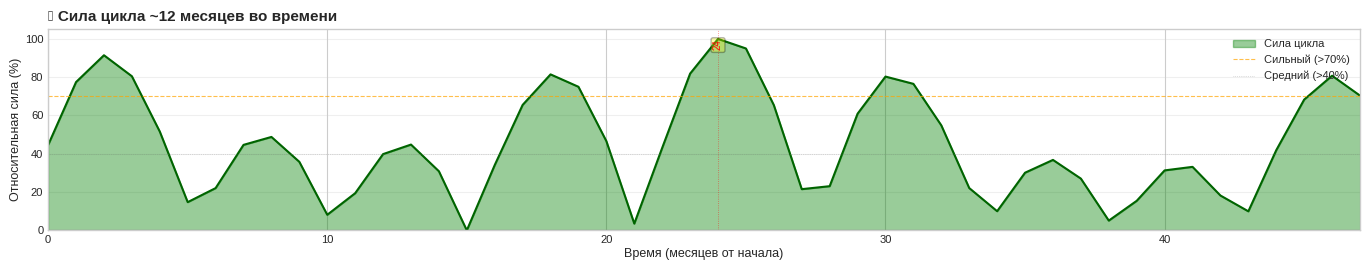


📊 Статистика цикла ~12 месяцев:
   • Средняя сила: 45.1%
   • Максимум: 100.0% (месяц 24)
   • Минимум: 0.0% (месяц 15)
   • Волатильность: 27.1%

⚠️ Цикл УМЕРЕННО изменчив — используйте фильтр по силе >50%

🔥 Периоды максимальной силы (>70%):
   • День 1
   • День 3
   • День 19
   • День 24
   • День 30
   • День 46


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# === Настройки анализа ===
TARGET_PERIOD = 12  # ← Меняйте под ваш доминирующий период

# Проверяем, что есть результаты из первой ячейки
if 'wavelet_results' not in locals():
    raise ValueError("Сначала выполните Ячейку 1!")

data = wavelet_results
t = data['t']
periods = data['periods'][data['period_mask']]
coefficients_plot = data['coefficients'][data['period_mask'], :]

# === Находим индекс нужного периода ===
freq = 1 / TARGET_PERIOD
scale_idx = np.argmin(np.abs(data['frequencies'] - freq))

if scale_idx >= len(periods):
    print(f"❌ Период {TARGET_PERIOD} месяцев не найден в диапазоне")
else:
    # === Извлекаем силу цикла во времени ===
    power_over_time = coefficients_plot[scale_idx, :]

    # Нормализация 0-100% для наглядности
    p_min, p_max = power_over_time.min(), power_over_time.max()
    power_norm = (power_over_time - p_min) / (p_max - p_min) * 100 if p_max > p_min else np.zeros_like(power_over_time)

    # === Визуализация ===
    fig, ax = plt.subplots(1, 1, figsize=(14, 3))

    # Заливка + линия
    ax.fill_between(t, 0, power_norm, color='green', alpha=0.4, label='Сила цикла')
    ax.plot(t, power_norm, color='darkgreen', linewidth=1.5)

    # Пороговые линии
    ax.axhline(y=70, color='orange', linestyle='--', linewidth=0.8, alpha=0.7, label='Сильный (>70%)')
    ax.axhline(y=40, color='gray', linestyle=':', linewidth=0.5, alpha=0.5, label='Средний (>40%)')
    ax.axhline(y=0, color='black', linewidth=0.3, alpha=0.3)

    # Подписи пиков
    peaks, _ = find_peaks(power_norm, height=60, distance=30)
    for peak_idx in peaks[:8]:  # максимум 8 подписей
        ax.axvline(x=t[peak_idx], color='red', linestyle=':', linewidth=0.6, alpha=0.5)
        ax.text(t[peak_idx], 95, f'{t[peak_idx]:.0f}', ha='center', fontsize=7,
               rotation=90, color='red', bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.3))

    # Оформление
    ax.set_title(f'🎯 Сила цикла ~{TARGET_PERIOD} месяцев во времени', fontweight='bold', loc='left', fontsize=11)
    ax.set_xlabel('Время (месяцев от начала)', labelpad=2)
    ax.set_ylabel('Относительная сила (%)', labelpad=2)
    ax.set_ylim(0, 105)
    ax.set_xlim(t.min(), t.max())
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    ax.tick_params(labelsize=8)

    plt.tight_layout(pad=2.0)
    plt.show()

    # === Статистика ===
    print(f"\n📊 Статистика цикла ~{TARGET_PERIOD} месяцев:")
    print(f"   • Средняя сила: {power_norm.mean():.1f}%")
    print(f"   • Максимум: {power_norm.max():.1f}% (месяц {t[np.argmax(power_norm)]:.0f})")
    print(f"   • Минимум: {power_norm.min():.1f}% (месяц {t[np.argmin(power_norm)]:.0f})")
    print(f"   • Волатильность: {power_norm.std():.1f}%")

    # Интерпретация
    stable_ratio = (power_norm.std() / power_norm.mean()) if power_norm.mean() > 0 else 0
    if stable_ratio < 0.4:
        print(f"\n💡 Цикл СТАБИЛЬНЫЙ — можно использовать в стратегии постоянно")
    elif stable_ratio < 0.7:
        print(f"\n⚠️ Цикл УМЕРЕННО изменчив — используйте фильтр по силе >50%")
    else:
        print(f"\n❗ Цикл НЕСТАБИЛЬНЫЙ — включайте стратегию только при силе >70%")

    # Когда был strongest
    strong_months = t[power_norm > 70]
    if len(strong_months) > 0:
        print(f"\n🔥 Периоды максимальной силы (>70%):")
        for month in strong_months[::max(1, len(strong_months)//5)]:  # не больше 5 подписей
            print(f"   • День {month:.0f}")

# Частичная автокорреляция

Это статистический метод, используемый для измерения автокорреляции временного ряда с его собственными задержками (лагами), но БЕЗ УЧЕТА влияния промежуточных лагов.

Она помогает выяснить, насколько наблюдение на шаге t связано с наблюдением на шаге t-k, если устранить влияние всех промежуточных значений между ними.

Когда мы рассчитываем автокорреляцию обычным способом (ACF, Autocorrelation Function), это включает все промежуточные значения, что может привести к ложным выводам о взаимосвязях между значениями временного ряда. PACF, в свою очередь, устраняет этот эффект, предоставляя "чистую" корреляцию между значениями через определённый лаг, устраняя влияние других лагов.

## Алгоритм вычисления

1. PACF на первом лаге просто равна корреляции между текущим значением и значением с лагом 1.

  $ PACF(1)=ACF(1)$

2. Частичная автокорреляция при лаге 2 и выше:
- Для вычисления PACF при лаге k, необходимо провести линейную регрессию текущего значения $X_t$ на предыдущие значения $X_{t-1}$,..., $X_{t-k}$ и оценить коэффициент при $X_{t-k}$.
- Для каждого значения k, частичная автокорреляция измеряет влияние задержки k, устраняя влияние всех промежуточных задержек.

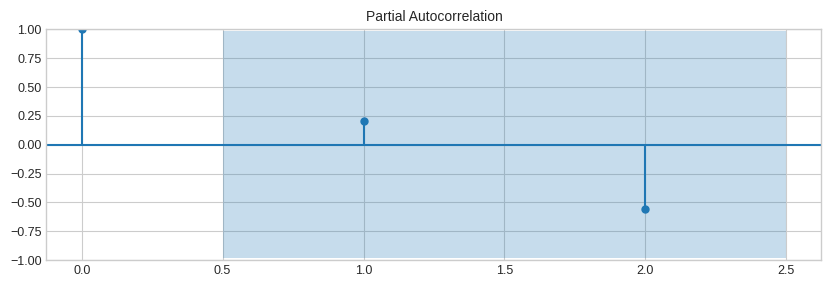

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

# Строим график частичной автокорреляции ПО МЕСЯЦАМ
fig = plot_pacf(df_year['SalesAmount'], lags=2)
fig.set_size_inches((10, 3))
plt.show()

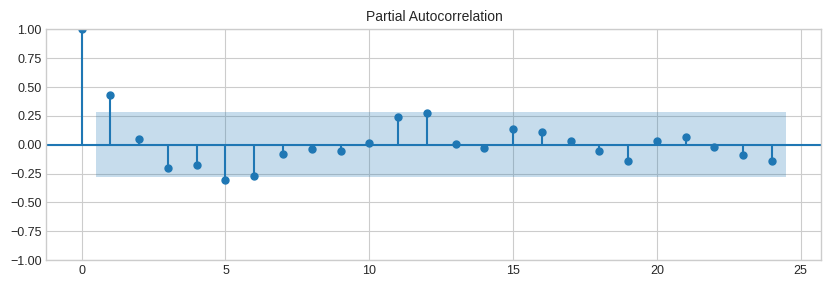

In [ ]:
# Для дней
fig = plot_pacf(df['SalesAmount'], lags=24)
fig.set_size_inches((10, 3))
plt.show()

**Интерпретация PACF-графика**
- Если значение на определённом лаге значительно отклоняется от 0, это говорит о том, что существует значительная частичная автокорреляция на этом лаге.
- Если график показывает, что только несколько первых лагов значимы, это может указывать на то, что временной ряд имеет короткую память и можно использовать модель AR с небольшим количеством лагов.

**Выводы:**

Частичная автокорреляционная функция позволяет выявить прямые зависимости между наблюдениями временного ряда без влияния промежуточных лагов.

Полученные результаты могут быть использованы для определения порядка авторегрессионной части моделей типа ARIMA.

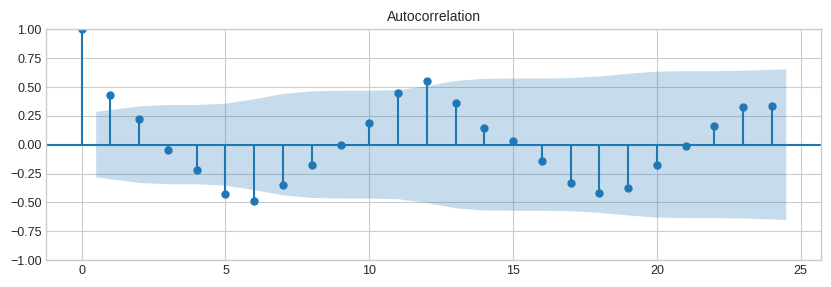

In [ ]:
# для сравнения график ACF
from statsmodels.graphics.tsaplots import plot_acf

fig = plot_acf(df['SalesAmount'].values.squeeze(), lags=24)
fig.set_size_inches((10, 3))
plt.show()

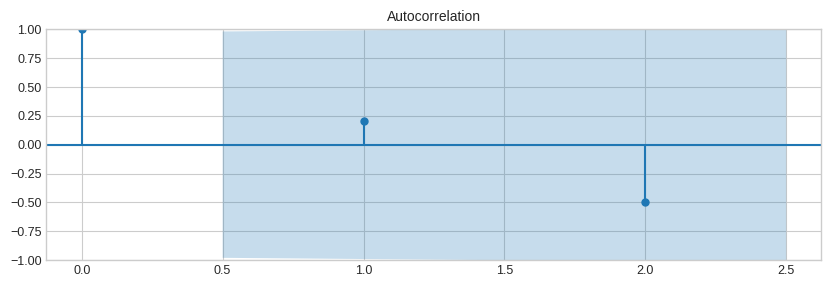

In [ ]:
fig = plot_acf(df_year['SalesAmount'].values.squeeze(), lags=2)
fig.set_size_inches((10, 3))
plt.show()

# Тесты на стационарность



Стационарность по ACF и PACF
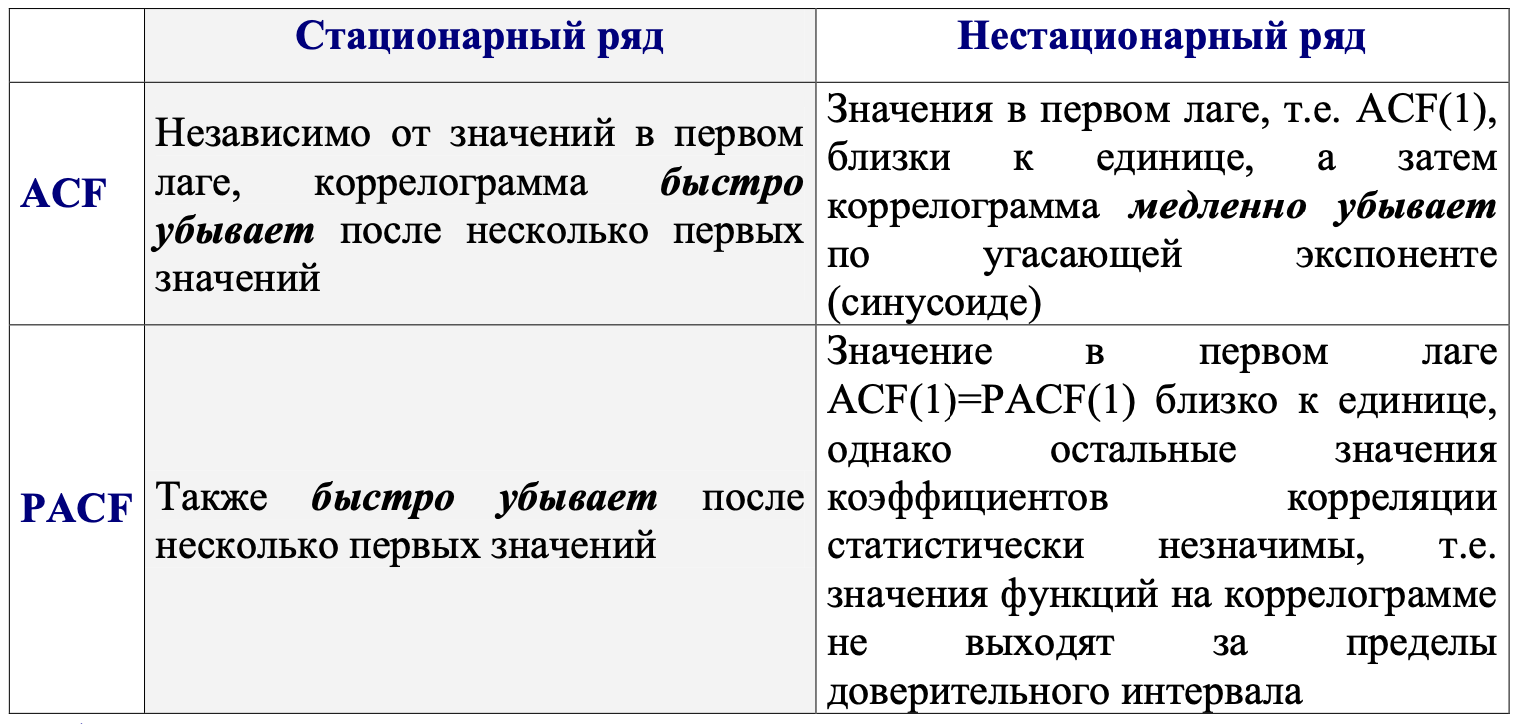

## ADF-тест (Расширенный тест Дики-Фуллера)

Модификация стандартного теста Дики-Фуллера.

Он применяется в случаях, когда предполагается наличие автокорреляции ошибок модели.


Для устранения этой проблемы в уравнение теста добавляются лагированные значения разности исследуемой переменной. Это позволяет скорректировать возможную взаимосвязь случайных отклонений.

In [ ]:
from statsmodels.tsa.stattools import adfuller

dftest = adfuller(df['SalesAmount'], autolag="AIC")
print(dftest[1])

0.00018535586430261453


**Вывод:**

*p-value = 0.000185*

Очень низкое значение (< 0.05)

***Нулевая гипотеза (ряд нестационарен) отвергается***

## KPSS-тест


В качестве нулевой гипотезы KPSS проверяет гипотезу о принадлежности ряда к стационарным

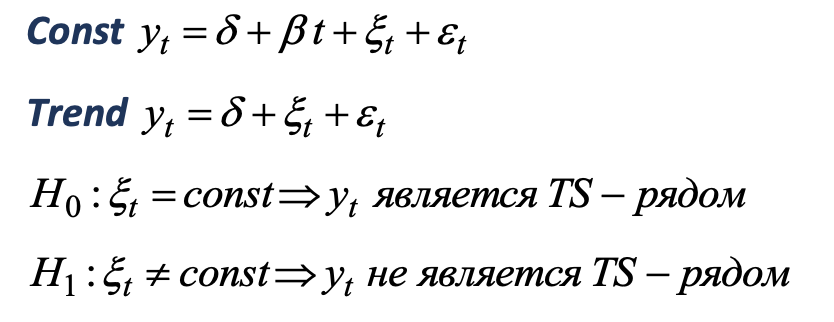

In [ ]:
from statsmodels.tsa.stattools import kpss

def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

kpss_test(df['SalesAmount'])

Results of KPSS Test:
Test Statistic           0.138846
p-value                  0.100000
Lags Used                3.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


/tmp/ipykernel_454/1638041274.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")


**Вывод:**
На основании уровня значимости 0,05 и значения p теста KPSS имеются доказательства того, что нулевая гипотеза не может быть отклонена. Следовательно, согласно тесту KPSS ряд стационарен.

## Согласование результатов тестов

| ADF тест | KPSS тест | Вывод |
|----------|-----------|--------|
| Отвергает H0 | Не отвергает H0 | Стационарный ряд |
| Не отвергает H0 | Отвергает H0 | DS (difference stationary) |
| Отвергает H0 | Отвергает H0 | TS (trend stationary) |
| Не отвергает H0 | Не отвергает H0 | Требуется дополнительный анализ |


**Класс TS** временных рядов – ряды, становящиеся стационарными после вычитания из них детерминированного тренда.

**Класс DS** временных рядов – нестационарные временные ряды, которые не относятся к классу TS-рядов, и которые приводятся к стационарным рядам однократным или многократным дифференцированием.

2) Дики-Фуллер не отвергает -> нестационарный; KPSS отвергает -> нестационарный

3) Дики-Фуллер отвергает -> стационарный; KPSS отвергает -> нестационарные

4)  Дики-Фуллер отвергает -> нестационарный; KPSS отвергает -> стационарные

**Совместный вывод ADF + KPSS:**

Оба теста согласованно показывают, что временной ряд продаж стационарен.

Это означает, что его можно использовать для построения статистических моделей без дополнительного дифференцирования.

# Простейшее прогнозирование с помощью линейной регрессии

## Шаги:
1. Подготовка данных временного ряда.
2. Создание временных лагов для преобразования временного ряда в набор данных для регрессии.
3. Обучение модели линейной регрессии на основе этих лагов.
4. Прогнозирование будущих значений.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# --- 1. СНАЧАЛА разделение на train и test ---
# shuffle=False критически важен для временных рядов!
train_df, test_df = train_test_split(df[['SalesAmount']], test_size=0.2, shuffle=False)

# --- 2. Функция создания лагов ---
def create_lagged_features(df, lag=3):
    df = df.copy()  # Чтобы не менять исходный датафрейм
    for i in range(1, lag + 1):
        df[f'lag_{i}'] = df['SalesAmount'].shift(i)
    return df

lag = 3

# --- 3. Создание лагов для TRAIN ---
X_train = create_lagged_features(train_df, lag)
y_train = X_train['SalesAmount']
X_train = X_train.drop(columns='SalesAmount')

# Удаляем первые строки с NaN (где не хватает истории для лагов)
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

# --- 4. Создание лагов для TEST ---
# ВАЖНО: Чтобы рассчитать лаги для первых строк теста, нам нужно "прошлое" из трейна
# Берем последние `lag` строк из train и приклеиваем к началу test
combined = pd.concat([train_df.iloc[-lag:], test_df])
X_test_full = create_lagged_features(combined, lag)

# Отрезаем добавленные строки трейна, оставляем только тест
X_test = X_test_full.iloc[lag:].drop(columns='SalesAmount')
y_test = X_test_full.iloc[lag:]['SalesAmount']

# Удаляем NaN, если они остались
X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]

# --- 5. Обучение и проверка ---
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"MSE: {mse:.4f}")

# Проверка, что нет утечки (индексы train и test не пересекаются)
print(f"Index overlap: {len(set(X_train.index) & set(X_test.index)) == 0}")

Train shape: (35, 3)
Test shape: (10, 3)
MSE: 5594181.6024
Index overlap: True


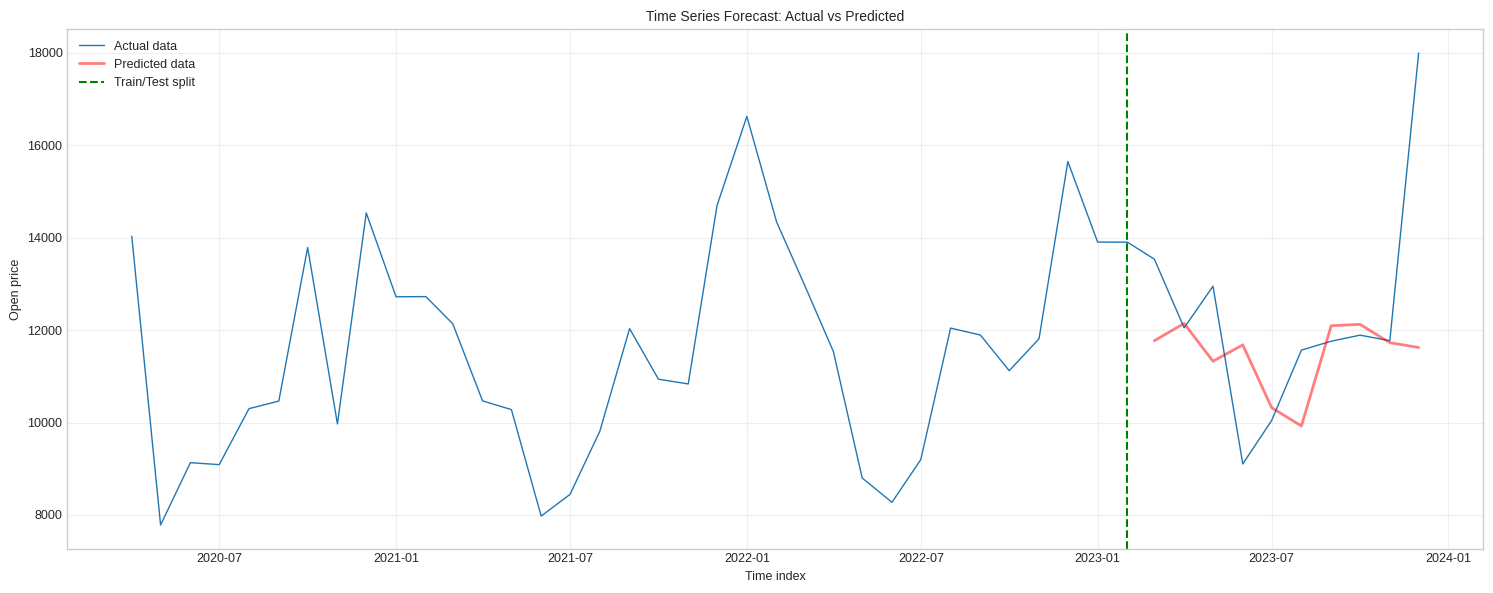

In [ ]:
# Визуализация прогноза
plt.figure(figsize=(15, 6))

# 1. Фактические данные: train + test (непрерывный временной ряд)
y_actual = pd.concat([y_train, y_test])
plt.plot(y_actual.index, y_actual.values, label="Actual data", alpha=1, linewidth=1)

# 2. Предсказания модели (только на тесте)
# Важно: y_pred и y_test имеют одинаковые индексы, используем их для корректного позиционирования
plt.plot(y_test.index, y_pred, label="Predicted data", color='red', linewidth=2, alpha=0.5)

# 3. Граница разделения train/test
split_point = y_train.index[-1]  # Последний индекс обучающей выборки
plt.axvline(x=split_point, color='green', linestyle='--', linewidth=1.5, label="Train/Test split")

# 4. Оформление
plt.xlabel("Time index")
plt.ylabel("Open price")
plt.title("Time Series Forecast: Actual vs Predicted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Анализ остатков модели: руководство по интерпретации

Остатки модели — это разность между фактическими наблюдаемыми значениями и значениями, предсказанными моделью. Качественная модель оставляет в остатках только случайный шум.

Для оценки адекватности модели анализируют три ключевых свойства остатков:
- постоянство дисперсии (гомоскедастичность);
- нормальность распределения;
- отсутствие автокорреляции.

---

## 1. Гомоскедастичность (постоянство дисперсии остатков)

**Что это означает:**  
Дисперсия остатков должна быть приблизительно одинаковой на всём протяжении ряда. Изменение дисперсии - гетероскедастичность

**Как проверить:**

1. **Графический анализ**  

2. **Статистический тест Бройша–Пагана**  
   - Нулевая гипотеза (H₀): дисперсия остатков постоянна (гомоскедастичность).
   - Альтернативная гипотеза (H₁): дисперсия остатков зависит от предикторов (гетероскедастичность).
   - Если p-значение > 0.05 — нет оснований отвергать H₀, дисперсия считается постоянной.
   - Если p-значение ≤ 0.05 — отвергаем H₀, присутствует гетероскедастичность. В этом случае рекомендуется:
     - проверить наличие пропущенных переменных или нелинейностей;
     - рассмотреть преобразование целевой переменной (например, логарифмирование);
     - использовать робастные стандартные ошибки или модели, учитывающие изменяющуюся дисперсию.

---

## 2. Нормальность распределения остатков

**Как проверить:**

1. **Гистограмма и плотность распределения**  

2. **Q-Q график (квантиль-квантиль)**  
   Сравнивает квантили остатков с квантилями теоретического нормального распределения. При нормальности точки располагаются близко к диагональной линии. Систематические отклонения (например, S-образная форма или выбросы на концах) указывают на асимметрию, тяжёлые хвосты или наличие аномалий.

3. **Тест Шапиро–Уилка**  
   Формальный тест на нормальность, особенно эффективный при небольших и средних объёмах выборки.
   - Нулевая гипотеза (H₀): остатки распределены нормально.
   - Альтернативная гипотеза (H₁): распределение остатков отличается от нормального.
   - Если p-значение > 0.05 — нет оснований отвергать нормальность.
   - Если p-значение ≤ 0.05 — отвергаем H₀, распределение не является нормальным.  
     В этом случае:
     - проверьте данные на наличие выбросов или ошибок измерения;
     - рассмотрите преобразование целевой переменной;
     - при больших выборках помните, что тесты на нормальность могут быть избыточно чувствительны к незначительным отклонениям — в таких случаях опирайтесь также на графические методы.

---

## 3. Отсутствие автокорреляции в остатках

1. **График автокорреляционной функции (ACF)**  

2. **Тест Льюнга–Бокса**  
   - Нулевая гипотеза (H₀): автокорреляция отсутствует (остатки — белый шум).
   - Альтернативная гипотеза (H₁): присутствует автокорреляция хотя бы на одном из проверенных лагов.
   - Если p-значение > 0.05 — нет оснований отвергать независимость остатков.
   - Если p-значение ≤ 0.05 — отвергаем H₀, обнаружена автокорреляция.  
     Рекомендации:
     - добавьте лаги в модель;
     - рассмотрите модели, явно учитывающие автокорреляцию;
     - проверьте, не пропущена ли сезонная компонента или тренд.

---

## Общие рекомендации по интерпретации статистических тестов

1. **Учитывайте объём выборки.**  
   При больших выборках даже незначительные отклонения от предположений могут приводить к малым p-значениям.

3. **Приоритет диагностики:**  
   Сначала убедитесь в отсутствии автокорреляции и гетероскедастичности. Нормальность важна преимущественно для статистического вывода, а не для точечных прогнозов.

ДИАГНОСТИКА МОДЕЛИ

[Шаг 1] Анализ обучающей выборки...

==================== TRAIN ====================
Breusch-Pagan p-value: 0.7367 → ✓
Jarque-Bera p-value: 0.7730 → ✓
Durbin-Watson: 2.0771 → ✓
R²: 0.3356

[Шаг 2] Анализ тестовой выборки...

==================== TEST ====================
Breusch-Pagan p-value: 0.9924 → ✓
Jarque-Bera p-value: 0.1075 → ✓
Durbin-Watson: 1.4007 → ⚠️
R²: -0.0962

СРАВНЕНИЕ ДИАГНОСТИКИ: TRAIN vs TEST
Тест                      | Train        | Test         | Статус         
------------------------------------------------------------
Homoscedasticity (BP)     | 0.7367       | 0.9924       | ✓ Согласовано  
Normality (JB)            | 0.7730       | 0.1075       | ✓ Согласовано  
Autocorrelation (DW)      | 2.0771       | 1.4007       | ⚠️ Расхождение 
R²                        | 0.3356       | -0.0962      | ⚠️ Падение качества

ИНТЕРПРЕТАЦИЯ

⚠️  Обнаружена положительная автокорреляция остатков.


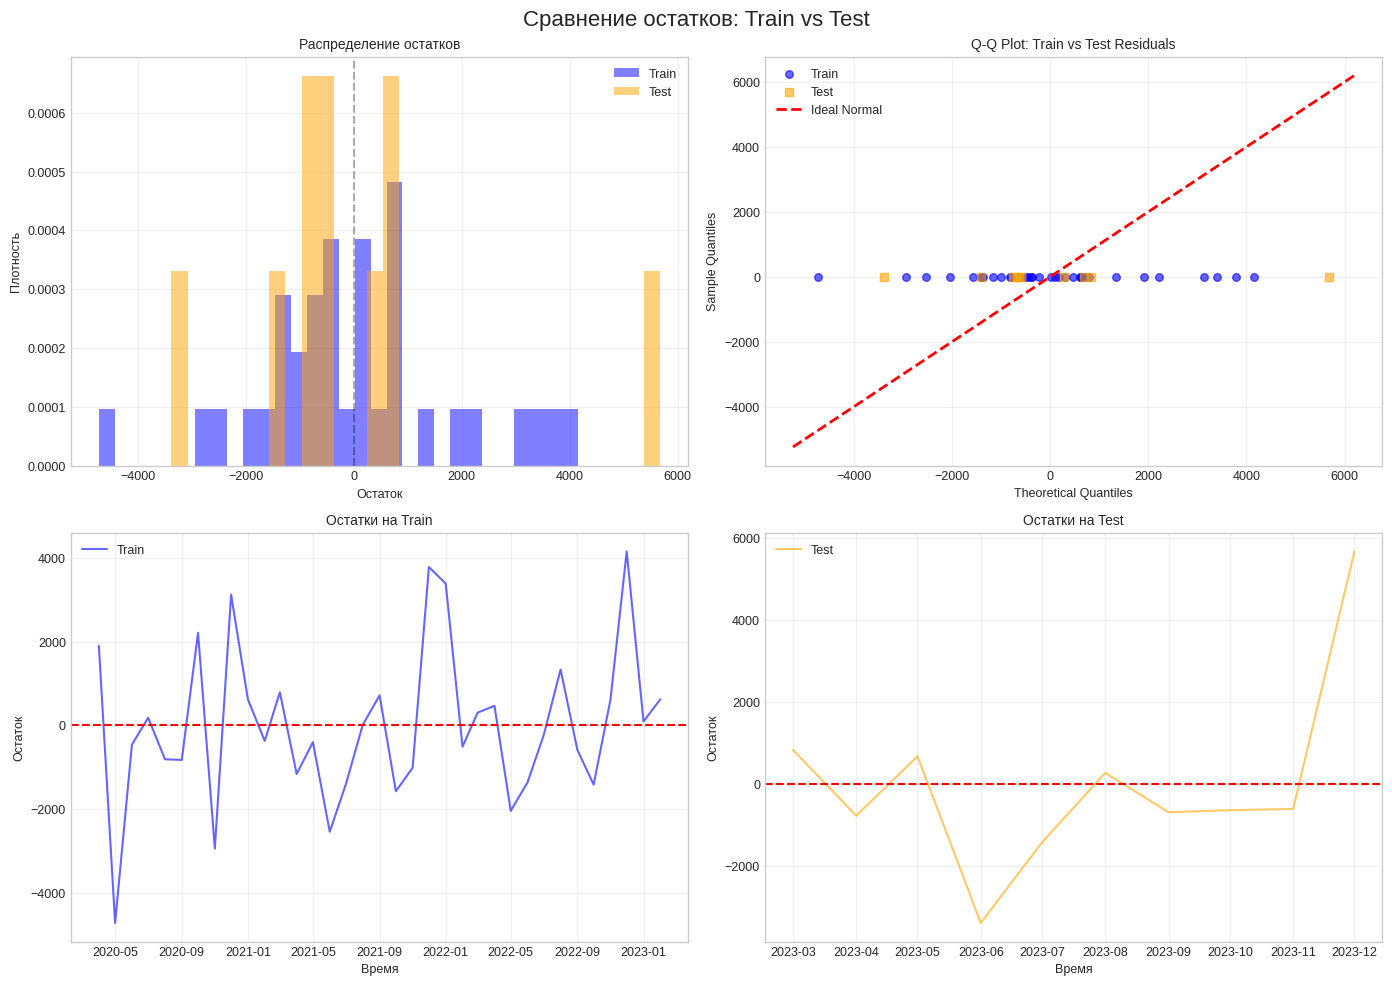

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

# -------------------------------------------------------------------------
# 1. ФУНКЦИЯ ДИАГНОСТИКИ
# -------------------------------------------------------------------------
def run_diagnostics(y_true, y_pred, X, dataset_name="Dataset"):
    """Проводит базовые диагностические тесты на остатках"""
    # Объединяем данные для удобства
    df_diag = pd.concat([y_true, X], axis=1).dropna()

    if len(df_diag) < 10:
        print(f"⚠️  {dataset_name}: недостаточно данных для диагностики (n={len(df_diag)})")
        return None

    # Формируем формулу динамически на основе колонок X
    features = ' + '.join(X.columns)
    formula = f'SalesAmount ~ {features}'

    try:
        model = smf.ols(formula=formula, data=df_diag).fit()
        residuals = model.resid
    except Exception as e:
        print(f"⚠️  {dataset_name}: ошибка при построении OLS модели: {e}")
        return None

    print(f"\n{'='*20} {dataset_name.upper()} {'='*20}")

    # 1. Breusch-Pagan (гомоскедастичность)
    try:
        bp_test = sm.stats.diagnostic.het_breuschpagan(residuals, model.model.exog)
        bp_pval = bp_test[1]
        print(f"Breusch-Pagan p-value: {bp_pval:.4f} → {'✓' if bp_pval >= 0.05 else '⚠️'}")
    except:
        bp_pval = np.nan
        print(f"Breusch-Pagan p-value: N/A")

    # 2. Jarque-Bera (нормальность)
    try:
        jb_test = sm.stats.jarque_bera(residuals)
        jb_pval = jb_test[1]
        print(f"Jarque-Bera p-value: {jb_pval:.4f} → {'✓' if jb_pval >= 0.05 else '⚠️'}")
    except:
        jb_pval = np.nan
        print(f"Jarque-Bera p-value: N/A")

    # 3. Durbin-Watson (автокорреляция)
    try:
        dw_stat = sm.stats.stattools.durbin_watson(residuals)
        dw_ok = 1.5 < dw_stat < 2.5
        print(f"Durbin-Watson: {dw_stat:.4f} → {'✓' if dw_ok else '⚠️'}")
    except:
        dw_stat = np.nan
        dw_ok = False
        print(f"Durbin-Watson: N/A")

    # 4. R²
    r2 = r2_score(y_true, y_pred)
    print(f"R²: {r2:.4f}")

    return {
        'bp_pval': bp_pval,
        'jb_pval': jb_pval,
        'dw_stat': dw_stat,
        'r2': r2,
        'residuals': residuals,
        'fitted': model.fittedvalues
    }

# -------------------------------------------------------------------------
# 2. ЗАПУСК ДИАГНОСТИКИ (Train и Test)
# -------------------------------------------------------------------------
print("="*60)
print("ДИАГНОСТИКА МОДЕЛИ")
print("="*60)

# Диагностика на TRAIN
print("\n[Шаг 1] Анализ обучающей выборки...")
train_results = run_diagnostics(y_train, model.predict(X_train), X_train, "TRAIN")

# Диагностика на TEST
print("\n[Шаг 2] Анализ тестовой выборки...")
test_results = run_diagnostics(y_test, model.predict(X_test), X_test, "TEST")

# -------------------------------------------------------------------------
# 3. СРАВНИТЕЛЬНАЯ ТАБЛИЦА
# -------------------------------------------------------------------------
if train_results and test_results:
    print(f"\n{'='*60}")
    print("СРАВНЕНИЕ ДИАГНОСТИКИ: TRAIN vs TEST")
    print("="*60)
    print(f"{'Тест':<25} | {'Train':<12} | {'Test':<12} | {'Статус':<15}")
    print("-"*60)

    # Breusch-Pagan
    bp_status = "✓ Согласовано" if (train_results['bp_pval']>=0.05) == (test_results['bp_pval']>=0.05) else "⚠️ Расхождение"
    print(f"{'Homoscedasticity (BP)':<25} | {train_results['bp_pval']:<12.4f} | {test_results['bp_pval']:<12.4f} | {bp_status:<15}")

    # Jarque-Bera
    jb_status = "✓ Согласовано" if (train_results['jb_pval']>=0.05) == (test_results['jb_pval']>=0.05) else "⚠️ Расхождение"
    print(f"{'Normality (JB)':<25} | {train_results['jb_pval']:<12.4f} | {test_results['jb_pval']:<12.4f} | {jb_status:<15}")

    # Durbin-Watson
    dw_train_ok = 1.5 < train_results['dw_stat'] < 2.5 if not np.isnan(train_results['dw_stat']) else False
    dw_test_ok = 1.5 < test_results['dw_stat'] < 2.5 if not np.isnan(test_results['dw_stat']) else False
    dw_status = "✓ Согласовано" if dw_train_ok == dw_test_ok else "⚠️ Расхождение"
    print(f"{'Autocorrelation (DW)':<25} | {train_results['dw_stat']:<12.4f} | {test_results['dw_stat']:<12.4f} | {dw_status:<15}")

    # R²
    r2_diff = abs(train_results['r2'] - test_results['r2'])
    r2_status = "✓ Стабильно" if r2_diff < 0.1 else "⚠️ Падение качества"
    print(f"{'R²':<25} | {train_results['r2']:<12.4f} | {test_results['r2']:<12.4f} | {r2_status:<15}")

# -------------------------------------------------------------------------
# 4. ИНТЕРПРЕТАЦИЯ
# -------------------------------------------------------------------------
if train_results and test_results:
    print(f"\n{'='*60}")
    print("ИНТЕРПРЕТАЦИЯ")
    print("="*60)

    # Проверка на переобучение
    if train_results['r2'] > 0.9 and test_results['r2'] < 0.5:
        print("⚠️  ВЫСОКИЙ РИСК ПЕРЕОБУЧЕНИЯ!")
        print("   Модель отлично работает на train, но плохо на test.")
    elif abs(train_results['r2'] - test_results['r2']) < 0.1:
        print("✓ Модель обобщает данные корректно (R² стабилен).")

    # Проверка предпосылок OLS
    if train_results['bp_pval'] < 0.05 or test_results['bp_pval'] < 0.05:
        print("\n⚠️  Обнаружена гетероскедастичность.")

    if train_results['dw_stat'] < 1.5 or test_results['dw_stat'] < 1.5:
        print("\n⚠️  Обнаружена положительная автокорреляция остатков.")

# -------------------------------------------------------------------------
# 5. ВИЗУАЛИЗАЦИЯ (ИСПРАВЛЕННАЯ)
# -------------------------------------------------------------------------
if train_results and test_results:
    # Создаем ЕДИНУЮ фигуру 2x2
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Сравнение остатков: Train vs Test', fontsize=16)

    # --- 1. Гистограммы остатков (axes[0, 0]) ---
    axes[0, 0].hist(train_results['residuals'], bins=30, alpha=0.5, label='Train', density=True, color='blue')
    axes[0, 0].hist(test_results['residuals'], bins=30, alpha=0.5, label='Test', density=True, color='orange')
    axes[0, 0].axvline(0, color='black', linestyle='--', alpha=0.3)
    axes[0, 0].set_xlabel('Остаток')
    axes[0, 0].set_ylabel('Плотность')
    axes[0, 0].set_title('Распределение остатков')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # --- 2. Q-Q plots (axes[0, 1]) ---
    # ИСПРАВЛЕНИЕ: правильная распаковка при fit=False
    ax_qq = axes[0, 1]

    # Train QQ данные
    # При fit=False probplot возвращает напрямую (osm, osr)
    train_osm, train_osr = stats.probplot(train_results['residuals'], dist="norm", fit=False)
    ax_qq.scatter(train_osr, train_osm, alpha=0.6, label='Train', color='blue', s=30, marker='o')

    # Test QQ данные
    test_osm, test_osr = stats.probplot(test_results['residuals'], dist="norm", fit=False)
    ax_qq.scatter(test_osr, test_osm, alpha=0.6, label='Test', color='orange', s=30, marker='s')

    # Добавляем ОДНУ референсную линию y=x
    min_val = min(ax_qq.get_xlim()[0], ax_qq.get_ylim()[0])
    max_val = max(ax_qq.get_xlim()[1], ax_qq.get_ylim()[1])
    ax_qq.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Normal')

    ax_qq.set_title('Q-Q Plot: Train vs Test Residuals')
    ax_qq.set_xlabel('Theoretical Quantiles')
    ax_qq.set_ylabel('Sample Quantiles')
    ax_qq.legend()
    ax_qq.grid(True, alpha=0.3)

    # --- 3. Остатки во времени (Train) (axes[1, 0]) ---
    axes[1, 0].plot(train_results['residuals'].index, train_results['residuals'].values,
                    alpha=0.6, label='Train', color='blue')
    axes[1, 0].axhline(0, color='red', linestyle='--')
    axes[1, 0].set_xlabel('Время')
    axes[1, 0].set_ylabel('Остаток')
    axes[1, 0].set_title('Остатки на Train')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # --- 4. Остатки во времени (Test) (axes[1, 1]) ---
    axes[1, 1].plot(test_results['residuals'].index, test_results['residuals'].values,
                    alpha=0.6, color='orange', label='Test')
    axes[1, 1].axhline(0, color='red', linestyle='--')
    axes[1, 1].set_xlabel('Время')
    axes[1, 1].set_ylabel('Остаток')
    axes[1, 1].set_title('Остатки на Test')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

**Выводы:**

Обучающая выборка:

	•	гетероскедастичность не обнаружена
	•	остатки нормально распределены
	•	автокорреляция остатков отсутствует
	•	модель объясняет ≈33% вариации продаж

Тестовая выборка:

	•	статистические предпосылки модели сохраняются
	•	однако качество прогноза ухудшается
Отрицательное значение R^2 означает, что модель хуже простого среднего прогноза.

#ARIMA

In [ ]:
# Разделение выборки на train/test
train_size = int(len(df)*0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

In [ ]:
#Подбор параметров модели ARIMA

from pmdarima import auto_arima

y = df['SalesAmount']
# auto_arima сам определит, сколько разностей нужно
model_1 = auto_arima(
    y,
    d=None,              # ← Автоматический подбор!
    seasonal=False,
    trace=True,
    stepwise=False # перебор всех комбинаций
)

print(f"Оптимальный порядок: {model_1.order}")

p, d, q = model_1.order

 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1039.743, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=991.558, Time=0.07 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=940.531, Time=0.24 sec
 ARIMA(0,0,5)(0,0,0)[0]             : AIC=inf, Time=0.22 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=883.996, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=883.740, Time=0.05 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=885.644, Time=0.08 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=880.911, Time=0.16 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=inf, Time=0.21 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=887.211, Time=0.12 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=882.818, Time=0.27 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, T

In [ ]:
# Подбор максимально возможного горизонта с сохранением приемлемого качества

from statsmodels.tsa.arima.model import ARIMA

# Предварительное обучение модели
model_fit = ARIMA(train['SalesAmount'], order=(p, d, q)).fit()

# Прогноз по шагам и вычисление RMSE
max_horizon = len(test['SalesAmount'])
rmse_list = []

for h in range(1, max_horizon + 1):
    forecast = model_fit.get_forecast(steps=h)
    pred = forecast.predicted_mean
    rmse = np.sqrt(mean_squared_error(test['SalesAmount'].iloc[:h], pred))
    rmse_list.append(rmse)

# Определение максимального горизонта с приемлемым качеством
mean_train = np.mean(train['SalesAmount'])
tolerance = 0.2 * mean_train  # например, 20% от среднего ряда

# Нахождение максимального шага, где RMSE <= tolerance
h_max = max(h for h, rmse in enumerate(rmse_list, 1) if rmse <= tolerance)
print(f"Максимально допустимый горизонт прогноза: {h_max} месяцев")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Максимально допустимый горизонт прогноза: 9 месяцев


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   48
Model:                 ARIMA(1, 0, 3)   Log Likelihood                -430.738
Date:                Fri, 13 Mar 2026   AIC                            873.476
Time:                        23:40:18   BIC                            884.704
Sample:                    01-01-2020   HQIC                           877.719
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.176e+04    179.576     65.465      0.000    1.14e+04    1.21e+04
ar.L1          0.8234      0.136      6.035      0.000       0.556       1.091
ma.L1         -0.4431      0.271     -1.632      0.1

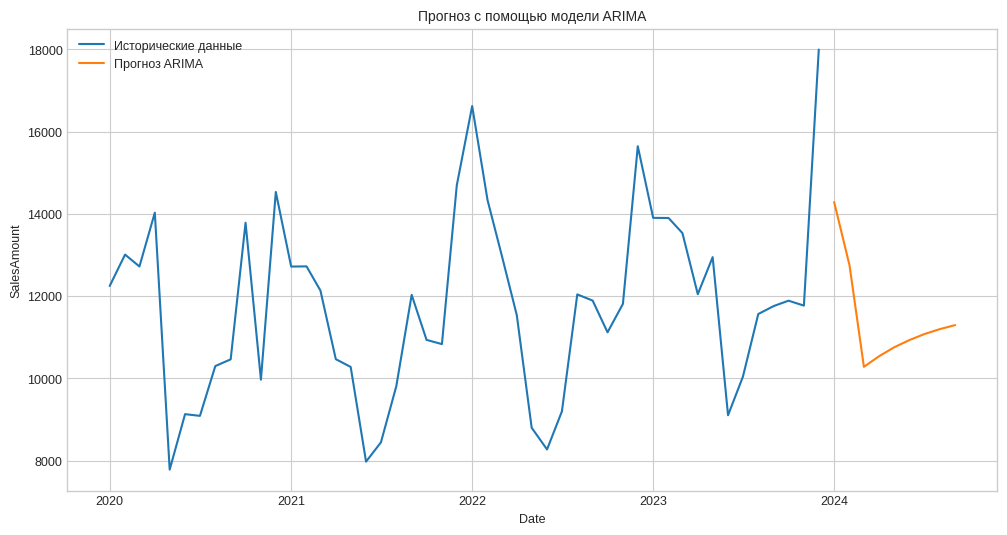

In [ ]:
#ARIMA
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(y, order=(p, d, q)).fit()
print(model_arima.summary())

# Прогноз на оптимальное число месяцев вперед
forecast_arima = model_arima.predict(start=len(y), end=len(y)+h_max-1, typ='levels')
plt.figure(figsize=(12, 6))
sns.lineplot(data=y, label='Исторические данные')
sns.lineplot(data=forecast_arima, label='Прогноз ARIMA')
plt.title('Прогноз с помощью модели ARIMA')
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing u

                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   38
Model:                 ARIMA(1, 0, 3)   Log Likelihood                -338.213
Date:                Fri, 13 Mar 2026   AIC                            688.426
Time:                        23:40:23   BIC                            698.252
Sample:                    01-01-2020   HQIC                           691.922
                         - 02-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.152e+04    151.427     76.047      0.000    1.12e+04    1.18e+04
ar.L1          0.7155      0.201      3.566      0.000       0.322       1.109
ma.L1         -0.4118      0.373     -1.104      0.2

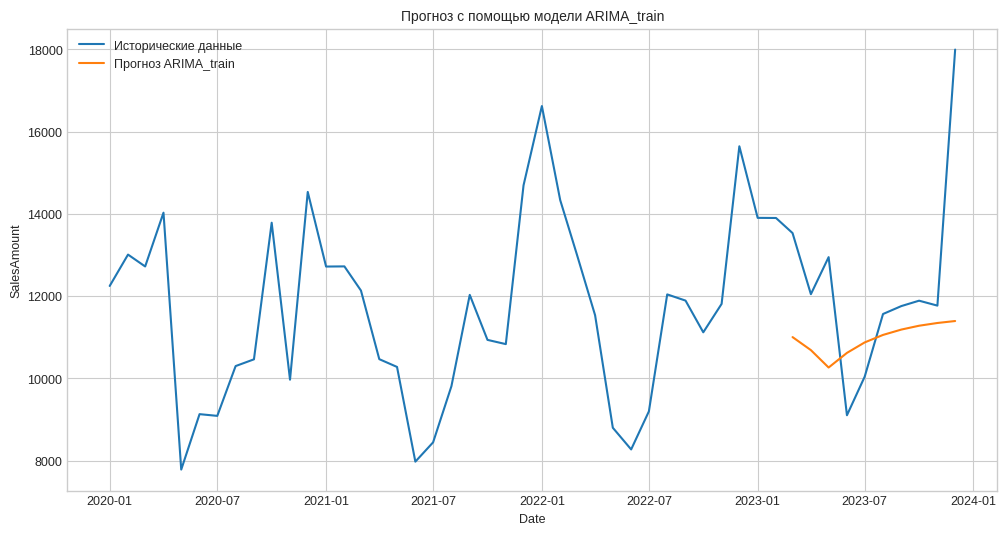

In [ ]:
#ARIMA train/test

model_arima_train = ARIMA(train['SalesAmount'], order=(p, d, q)).fit()
print(model_arima_train.summary())

# Прогноз на оптимальное число месяцев вперед
forecast_arima_train = model_arima_train.predict(start=len(train['SalesAmount']), end=len(train['SalesAmount'])+len(test['SalesAmount'])-1, typ='levels')
plt.figure(figsize=(12, 6))
sns.lineplot(data=y, label='Исторические данные')
sns.lineplot(data=forecast_arima_train, label='Прогноз ARIMA_train')
plt.title('Прогноз с помощью модели ARIMA_train')
plt.show()

**Вывод:**

В рамках исследования динамики временного ряда месячных продаж была построена модель авторегрессии со скользящим средним ARIMA(1,0,3). Выбор данной структуры обусловлен результатами автоматического подбора параметров, а также анализом информационных критериев. Согласно результатам оценки модели, значение логарифма функции правдоподобия составило −430.738, что соответствует информационным критериям AIC = 873.48 и BIC = 884.70 для полной выборки из 48 наблюдений.

Интерпретация коэффициентов модели ARIMA связана с анализом влияния прошлых значений временного ряда и ошибок прогнозирования. Параметр авторегрессии первого порядка (AR(1)) отражает степень зависимости текущего значения продаж от предыдущего периода. Наличие положительного авторегрессионного коэффициента свидетельствует о том, что увеличение продаж в предыдущем месяце повышает вероятность более высокого уровня продаж в текущем месяце. Это подтверждает существование инерционности динамики спроса.

Компонента скользящего среднего третьего порядка (MA(3)) учитывает влияние ошибок прогнозирования за три предыдущих периода. Экономическая интерпретация данного компонента заключается в корректировке прогноза с учетом случайных отклонений, возникавших в предыдущие месяцы. Это позволяет модели более гибко реагировать на краткосрочные колебания временного ряда.

Качество модели было дополнительно оценено на тестовой выборке. Согласно результатам расчёта метрик качества прогнозирования, среднеквадратичная ошибка модели, построенной на полной выборке, составила MSE = 3 620 713.31, а коэффициент детерминации R² = 0.2745. Данное значение коэффициента детерминации означает, что модель объясняет приблизительно 27.45% дисперсии наблюдаемых значений временного ряда. Таким образом, ARIMA-модель способна частично воспроизводить структуру временного ряда, однако значительная доля вариации остается необъясненной.

Следует отметить, что сравнительно невысокое значение R² указывает на ограниченную способность модели учитывать внешние факторы, влияющие на динамику продаж. Поскольку ARIMA учитывает исключительно внутреннюю структуру временного ряда (лаговые значения и случайные ошибки), она не способна напрямую моделировать влияние маркетинговых кампаний или сезонных событий.

Таким образом, модель ARIMA демонстрирует удовлетворительные, но ограниченные прогностические свойства. Она адекватно описывает автокорреляционную структуру ряда, однако не полностью отражает экономическую природу наблюдаемых колебаний продаж.

#SARIMAX

In [ ]:
#Подбор параметров модели SARIMAX

# Автоматический поиск лучших параметров
model_auto = auto_arima(
    y,
    exogenous=df[['Promotion','HolidayMonth']],
    d=None,              # ← Автоматический подбор!
    seasonal=True,
    m=12,  # или 365 для дневных данных
    trace=True,
    #error_action='ignore',
    suppress_warnings=True,
    stepwise=False # перебор всех комбинаций
)

print(f"Лучшие параметры: {model_auto.order}{model_auto.seasonal_order}")

p1, d1, q1 = model_auto.order
P, D, Q, m = model_auto.seasonal_order

 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=880.523, Time=0.01 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=865.848, Time=0.10 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=inf, Time=0.44 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=856.096, Time=0.16 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=871.908, Time=0.08 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=inf, Time=0.63 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=881.190, Time=0.18 sec
 ARIMA(0,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.85 sec
 ARIMA(0,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=0.81 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=874.567, Time=0.02 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=866.078, Time=0.16 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=860.195, Time=0.41 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=875.822, Time=0.06 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=867.772, Time=0.48 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=inf, Time=2.83 sec
 ARIMA(0,0,1)(2,0,0)[12] inter

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


                                SARIMAX Results                                 
Dep. Variable:              SalesAmount   No. Observations:                   48
Model:             SARIMAX(1, 0, 0, 12)   Log Likelihood                -447.163
Date:                  Fri, 13 Mar 2026   AIC                            898.325
Time:                          23:41:33   BIC                            902.068
Sample:                      01-01-2020   HQIC                           899.739
                           - 12-01-2023                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       0.9913      0.012     80.993      0.000       0.967       1.015
sigma2      2.581e+06    6.1e-11   4.23e+16      0.000    2.58e+06    2.58e+06
Ljung-Box (L1) (Q):                 

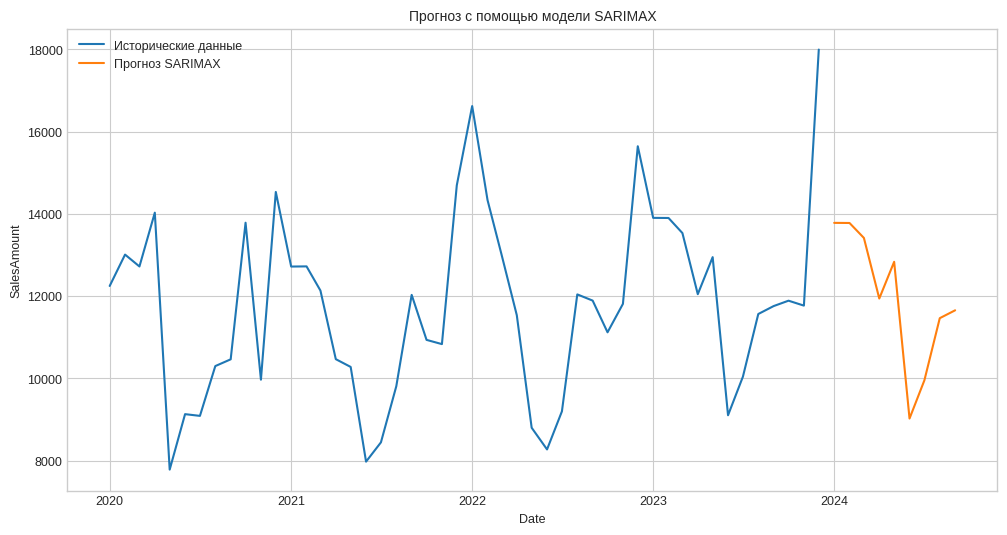

In [ ]:
#SARIMAX

model_sarimax = SARIMAX(y, order=(p1, d1, q1), seasonal_order=(P, D, Q, m)).fit()
print(model_sarimax.summary())

# Прогноз на оптимальное число месяцев вперед
forecast_sarimax = model_sarimax.predict(start=len(y), end=len(y)+h_max-1, typ='levels')
plt.figure(figsize=(12, 6))
sns.lineplot(data=y, label='Исторические данные')
sns.lineplot(data=forecast_sarimax, label='Прогноз SARIMAX')
plt.title('Прогноз с помощью модели SARIMAX')
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


                                SARIMAX Results                                 
Dep. Variable:              SalesAmount   No. Observations:                   38
Model:             SARIMAX(1, 0, 0, 12)   Log Likelihood                -358.830
Date:                  Fri, 13 Mar 2026   AIC                            721.660
Time:                          23:41:38   BIC                            724.935
Sample:                      01-01-2020   HQIC                           722.825
                           - 02-01-2023                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       0.9903      0.014     72.970      0.000       0.964       1.017
sigma2       2.69e+06    3.5e-11   7.69e+16      0.000    2.69e+06    2.69e+06
Ljung-Box (L1) (Q):                 

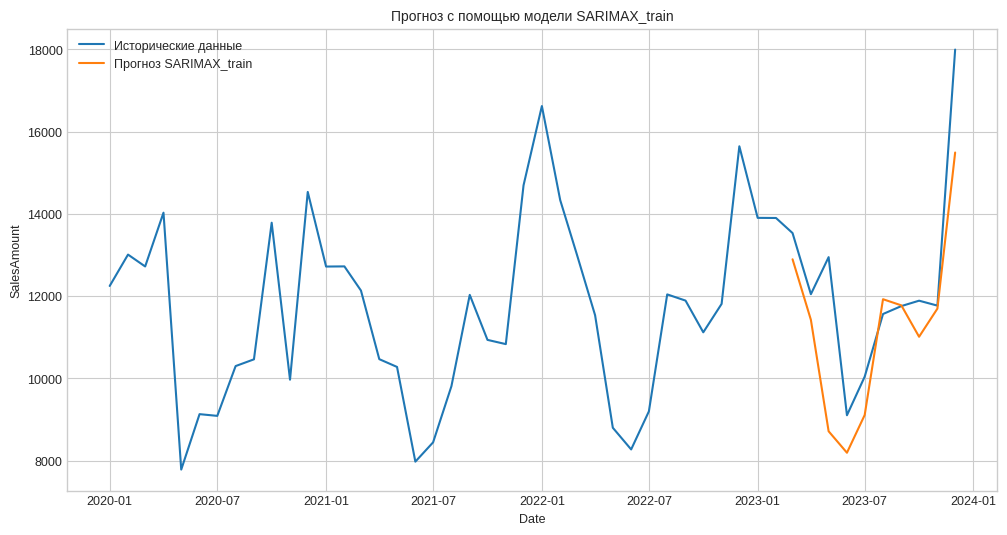

In [ ]:
#SARIMAX train/test

model_sarimax_train = SARIMAX(train['SalesAmount'], order=(p1, d1, q1), seasonal_order=(P, D, Q, m)).fit()
print(model_sarimax_train.summary())

# Прогноз на test
forecast_sarimax_train = model_sarimax_train.predict(start=len(train['SalesAmount']), end=len(train['SalesAmount'])+len(test['SalesAmount'])-1, typ='levels')
plt.figure(figsize=(12, 6))
sns.lineplot(data=y, label='Исторические данные')
sns.lineplot(data=forecast_sarimax_train, label='Прогноз SARIMAX_train')
plt.title('Прогноз с помощью модели SARIMAX_train')
plt.show()

**Вывод:**

Следующим этапом исследования стало построение модели SARIMAX, позволяющей учитывать сезонную структуру временного ряда. В рамках анализа была рассмотрена модель SARIMAX(1,0,0,12), где сезонный лаг равен 12, что соответствует годовой сезонности для месячных данных.

По результатам оценки модели для полной выборки значение логарифма функции правдоподобия составило −447.163, что соответствует информационным критериям AIC = 898.33 и BIC = 902.07. Данные значения превышают аналогичные показатели модели ARIMA, что свидетельствует о менее эффективном компромиссе между точностью модели и числом параметров.

Коэффициент авторегрессии первого порядка отражает влияние значения продаж в предыдущем месяце на текущий уровень продаж. Положительное значение данного коэффициента подтверждает наличие устойчивой временной зависимости в данных.

Сезонный компонент модели учитывает повторяющиеся годовые колебания спроса, характерные для розничной торговли. В экономическом контексте подобные колебания могут быть связаны с сезонными факторами, такими как праздничные периоды, изменение потребительской активности в различные месяцы года и циклические особенности рынка.

Однако результаты оценки прогностической способности модели показали крайне низкое качество прогнозирования. Среднеквадратичная ошибка модели, построенной на полной выборке, составила MSE = 35 805 205.09, а коэффициент детерминации оказался отрицательным и равным R² = −6.1749.

Отрицательное значение R² означает, что прогнозы модели оказываются хуже, чем простое использование среднего значения временного ряда. Это свидетельствует о том, что выбранная спецификация SARIMAX без экзогенных переменных не способна корректно воспроизвести структуру временного ряда продаж.

Таким образом, несмотря на учет сезонности, модель SARIMAX без дополнительных объясняющих переменных демонстрирует неудовлетворительное качество прогнозирования и не может рассматриваться как эффективный инструмент анализа рассматриваемого временного ряда.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                SARIMAX Results                                 
Dep. Variable:              SalesAmount   No. Observations:                   48
Model:             SARIMAX(1, 0, 0, 12)   Log Likelihood                -426.748
Date:                  Fri, 13 Mar 2026   AIC                            861.495
Time:                          23:41:22   BIC                            868.980
Sample:                      01-01-2020   HQIC                           864.324
                           - 12-01-2023                                         
Covariance Type:                    opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     2808.3266    317.314      8.850      0.000    2186.402    3430.251
HolidayMonth  1.574e+04   7.23e+04      0.218      0.828   -1.26e+05    1.57e+05
ar.S.L12         0.9960     

/tmp/ipykernel_454/1842480536.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_dates = pd.date_range(


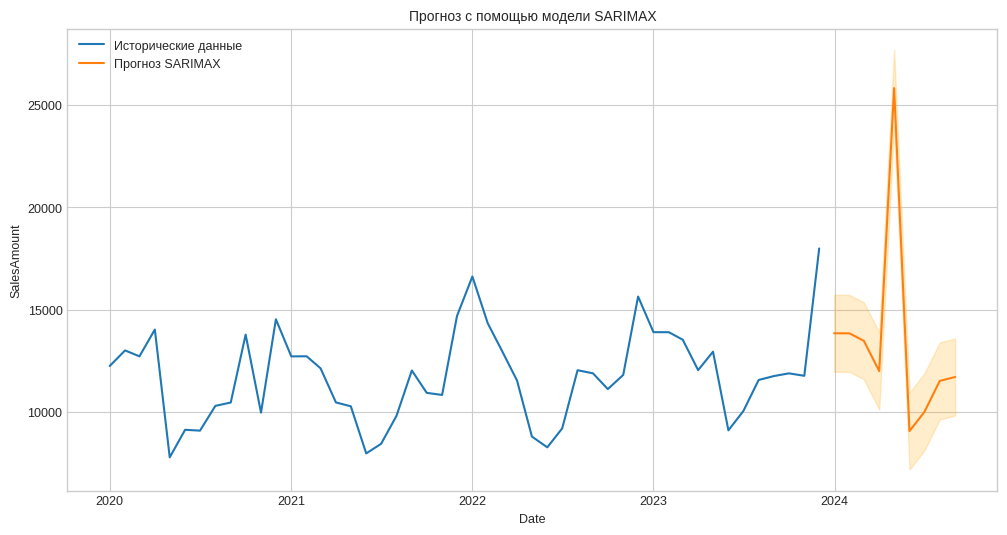

In [ ]:
#SARIMAX с экзогенными переменными
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarimax_exog = SARIMAX(y, order=(p1, d1, q1), seasonal_order=(P, D, Q, m), exog=df[['Promotion','HolidayMonth']]).fit()
print(model_sarimax_exog.summary())

# Создаём даты для прогноза
forecast_dates = pd.date_range(
    start=y.index[-1] + pd.offsets.MonthEnd(1),
    periods=h_max,
    freq='M'
)

# ⚠️ ВАЖНО: Создаем экзогенные переменные для будущего периода

exog_future = pd.DataFrame(index=forecast_dates)

#Повторяем последние 12 месяцев
last_year_holidaymonth = df['HolidayMonth'][-12:].values  # последние 12 месяцев
exog_future['HolidayMonth'] = np.tile(last_year_holidaymonth, int(np.ceil(len(forecast_dates)/12)))[:len(forecast_dates)]

last_year_promotion = df['Promotion'][-12:].values  # последние 12 месяцев
exog_future['Promotion'] = np.tile(last_year_promotion, int(np.ceil(len(forecast_dates)/12)))[:len(forecast_dates)]

# Делаем прогноз
forecast = model_sarimax_exog.get_forecast(
    steps=len(forecast_dates),
    exog=exog_future
)

forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Присваиваем правильные индексы
forecast_mean.index = forecast_dates
forecast_ci.index = forecast_dates

# Визуализация прогноза
plt.figure(figsize=(12, 6))
sns.lineplot(data=y, label='Исторические данные')
sns.lineplot(data=forecast_mean, label='Прогноз SARIMAX')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1], color='orange', alpha=0.2, label='доверительный интервал')
plt.title('Прогноз с помощью модели SARIMAX')
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                SARIMAX Results                                 
Dep. Variable:              SalesAmount   No. Observations:                   38
Model:             SARIMAX(1, 0, 0, 12)   Log Likelihood                -343.070
Date:                  Fri, 13 Mar 2026   AIC                            694.141
Time:                          23:41:28   BIC                            700.691
Sample:                      01-01-2020   HQIC                           696.471
                           - 02-01-2023                                         
Covariance Type:                    opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     2611.0576    352.307      7.411      0.000    1920.548    3301.567
HolidayMonth  1.496e+04      0.009   1.63e+06      0.000     1.5e+04     1.5e+04
ar.S.L12         0.9961     

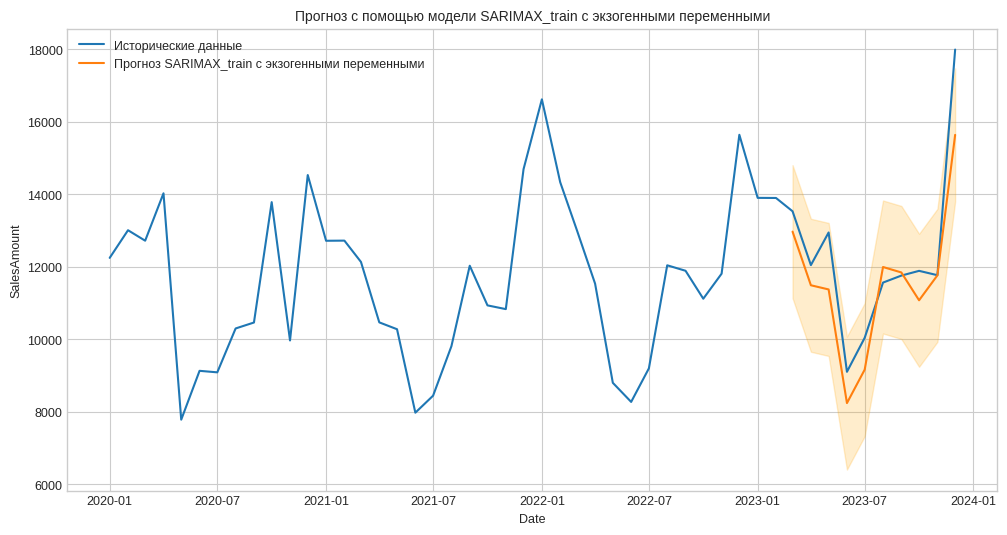

In [ ]:
#SARIMAX с экзогенными переменными train/test

model_sarimax_exog_train = SARIMAX(train['SalesAmount'], order=(p1, d1, q1), seasonal_order=(P, D, Q, m), exog=train[['Promotion','HolidayMonth']]).fit()
print(model_sarimax_exog_train.summary())

# ⚠️ ВАЖНО: Создаем экзогенные переменные для test
exog_test = test[['Promotion','HolidayMonth']]

# Делаем прогноз
forecast_train = model_sarimax_exog_train.get_forecast(
    steps=len(test),
    exog=exog_test
)

forecast_mean_train = forecast_train.predicted_mean
forecast_ci_train = forecast_train.conf_int()

# Присваиваем правильные индексы
forecast_mean_train.index = test.index
forecast_ci_train.index = test.index

# Визуализация прогноза
plt.figure(figsize=(12, 6))
sns.lineplot(data=y, label='Исторические данные')
sns.lineplot(data=forecast_mean_train, label='Прогноз SARIMAX_train с экзогенными переменными')
plt.fill_between(forecast_ci_train.index, forecast_ci_train.iloc[:,0], forecast_ci_train.iloc[:,1], color='orange', alpha=0.2, label='доверительный интервал')
plt.title('Прогноз с помощью модели SARIMAX_train с экзогенными переменными')
plt.show()

**Вывод:**

Для повышения качества моделирования была построена расширенная модель SARIMAX с включением экзогенных переменных, отражающих влияние маркетинговых и календарных факторов на динамику продаж. В качестве внешних регрессоров использовались переменные Promotion и HolidayMonth.

Переменная Promotion отражает наличие рекламной или маркетинговой активности в конкретном месяце. Положительное значение соответствующего коэффициента свидетельствует о том, что проведение промоакций приводит к увеличению объема продаж. Экономически это интерпретируется как прямой эффект стимулирования спроса.

Переменная HolidayMonth отражает наличие праздничных периодов. Значение соответствующего коэффициента характеризует влияние праздничных месяцев на уровень продаж. В розничной торговле такие периоды обычно сопровождаются повышенным потребительским спросом, что делает данную переменную важным фактором модели.

Результаты оценки прогностической способности данной модели оказались существенно лучше по сравнению с предыдущими моделями. Среднеквадратичная ошибка модели, построенной на полной выборке, составила MSE = 1 629 273.38, а коэффициент детерминации достиг значения R² = 0.6735.

Это означает, что модель объясняет около 67.35% вариации временного ряда продаж. Таким образом, учет внешних факторов существенно повышает точность прогнозирования.

Для модели, построенной на обучающей выборке, качество модели также оказалось высоким: MSE = 1 100 589.17 и R² = 0.7843. Это свидетельствует о том, что модель адекватно описывает структуру данных и не демонстрирует признаков значительного переобучения.

Таким образом, включение экзогенных переменных позволяет значительно повысить объясняющую способность модели и улучшить качество прогнозирования.

#Метрики качества прогноза

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Прогноз на исторических данных
# ARIMA
arima_in_sample_pred = model_arima.predict(start=0, end=len(y)-1, typ='levels')
# SARIMAX
sarimax_in_sample_pred = model_sarimax.predict(start=0, end=len(y)-1, typ='levels')
# SARIMAX с exog
sarimax_exog_in_sample_forecast = model_sarimax_exog.get_forecast(
    steps=len(y),
    exog=df[['Promotion','HolidayMonth']]
)
sarimax_exog_in_sample_pred = sarimax_exog_in_sample_forecast.predicted_mean
sarimax_exog_in_sample_pred.index = y.index

# MSE
arima_mse = mean_squared_error(y, arima_in_sample_pred)
sarimax_mse = mean_squared_error(y, sarimax_in_sample_pred)
sarimax_exog_mse = mean_squared_error(y, sarimax_exog_in_sample_pred)

arima_train_mse = mean_squared_error(test['SalesAmount'], forecast_arima_train)
sarimax_train_mse = mean_squared_error(test['SalesAmount'], forecast_sarimax_train)
sarimax_exog_train_mse = mean_squared_error(test['SalesAmount'], forecast_mean_train)

# R²
arima_r2 = r2_score(y, arima_in_sample_pred)
sarimax_r2 = r2_score(y, sarimax_in_sample_pred)
sarimax_exog_r2 = r2_score(y, sarimax_exog_in_sample_pred)

arima_train_r2 = r2_score(test['SalesAmount'], forecast_arima_train)
sarimax_train_r2 = r2_score(test['SalesAmount'], forecast_sarimax_train)
sarimax_exog_train_r2 = r2_score(test['SalesAmount'], forecast_mean_train)

# Вывод результатов
print(f"ARIMA — MSE: {arima_mse:.2f}, R²: {arima_r2:.4f}")
print(f"SARIMAX — MSE: {sarimax_mse:.2f}, R²: {sarimax_r2:.4f}")
print(f"SARIMAX_exog — MSE: {sarimax_exog_mse:.2f}, R²: {sarimax_exog_r2:.4f}")

print(f"ARIMA_train — MSE: {arima_train_mse:.2f}, R²: {arima_train_r2:.4f}")
print(f"SARIMAX_train — MSE: {sarimax_train_mse:.2f}, R²: {sarimax_train_r2:.4f}")
print(f"SARIMAX_exog_train — MSE: {sarimax_exog_train_mse:.2f}, R²: {sarimax_exog_train_r2:.4f}")

# Сравнение моделей
models = {
    'ARIMA': {'mse': arima_mse, 'r2': arima_r2},
    'SARIMAX': {'mse': sarimax_mse, 'r2': sarimax_r2},
    'SARIMAX_exog': {'mse': sarimax_exog_mse, 'r2': sarimax_exog_r2},
    'ARIMA_train': {'mse': arima_train_mse, 'r2': arima_train_r2},
    'SARIMAX_train': {'mse': sarimax_train_mse, 'r2': sarimax_train_r2},
    'SARIMAX_exog_train': {'mse': sarimax_exog_train_mse, 'r2': sarimax_exog_train_r2}
}

# Лучшая модель по MSE (минимум)
best_mse_model = min(models, key=lambda k: models[k]['mse'])

# Лучшая модель по R² (максимум)
best_r2_model = max(models, key=lambda k: models[k]['r2'])

print(f"Лучшая модель по MSE: {best_mse_model}")
print(f"Лучшая модель по R²: {best_r2_model}")

ARIMA — MSE: 3620713.31, R²: 0.2745
SARIMAX — MSE: 35805205.09, R²: -6.1749
SARIMAX_exog — MSE: 1629273.38, R²: 0.6735
ARIMA_train — MSE: 6314719.51, R²: -0.2374
SARIMAX_train — MSE: 2759700.10, R²: 0.4592
SARIMAX_exog_train — MSE: 1100589.17, R²: 0.7843
Лучшая модель по MSE: SARIMAX_exog_train
Лучшая модель по R²: SARIMAX_exog_train


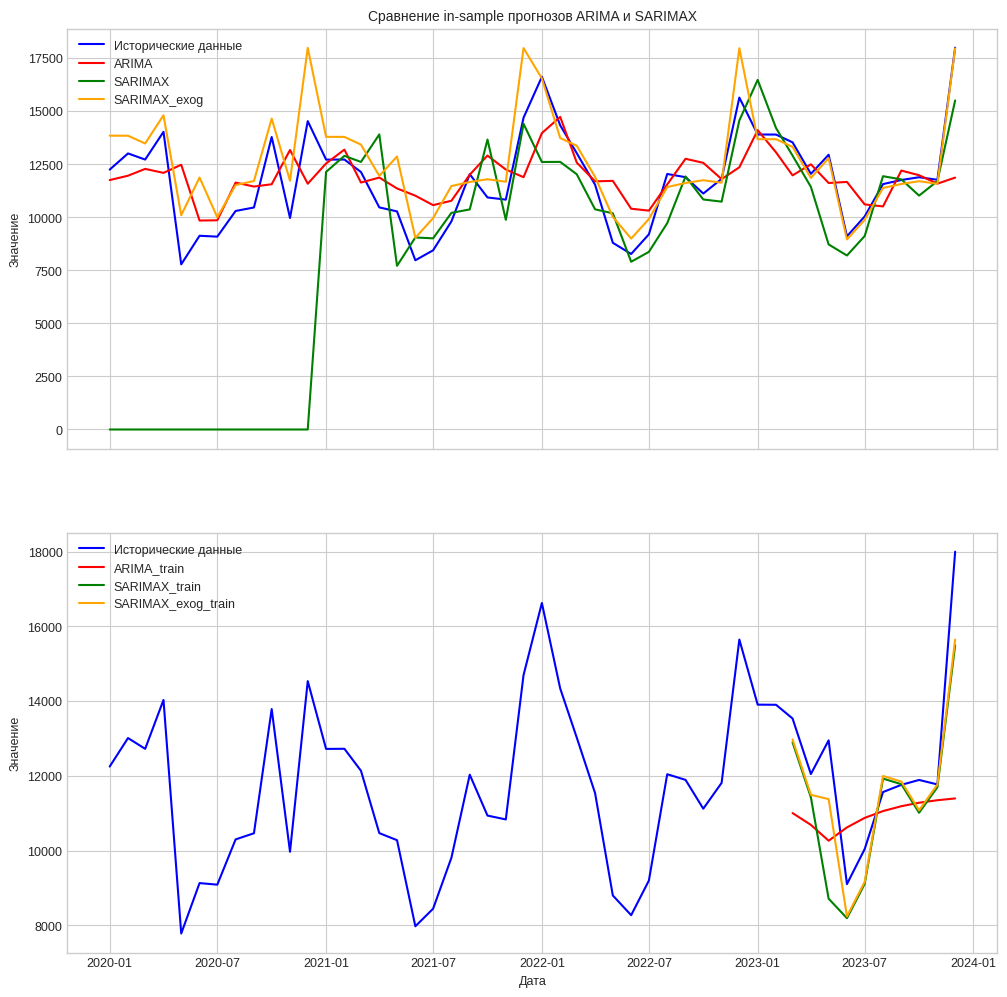

In [ ]:
# Визуализация метрик качества прогноза
#plt.figure(figsize=(14,6))
fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

# Исторические данные
sns.lineplot(data=y, label='Исторические данные', color='blue', ax=axes[0])
sns.lineplot(data=y, label='Исторические данные', color='blue', ax=axes[1])

# ARIMA
sns.lineplot(data=arima_in_sample_pred, label='ARIMA', color='red', ax=axes[0])
sns.lineplot(data=forecast_arima_train, label='ARIMA_train', color='red', ax=axes[1])

# SARIMAX
sns.lineplot(data=sarimax_in_sample_pred, label='SARIMAX', color='green', ax=axes[0])
sns.lineplot(data=forecast_sarimax_train, label='SARIMAX_train', color='green', ax=axes[1])

# SARIMAX с exog
sns.lineplot(data=sarimax_exog_in_sample_pred, label='SARIMAX_exog', color='orange', ax=axes[0])
sns.lineplot(data=forecast_mean_train, label='SARIMAX_exog_train', color='orange', ax=axes[1])

axes[0].set_title('Сравнение in-sample прогнозов ARIMA и SARIMAX')
plt.xlabel('Дата')
axes[0].set_ylabel('Значение')
axes[1].set_ylabel('Значение')
plt.legend()
plt.show()

**Вывод:**

Для количественной оценки качества построенных моделей были использованы метрики MSE и коэффициент детерминации R².

Для моделей, построенных на полной выборке:

	•	ARIMA: MSE = 3 620 713.31, R² = 0.2745
	•	SARIMAX: MSE = 35 805 205.09, R² = −6.1749
	•	SARIMAX с экзогенными переменными: MSE = 1 629 273.38, R² = 0.6735

Для моделей, построенных на обучающей выборке:

	•	ARIMA: MSE = 6 314 719.51, R²: -0.2374
	•	SARIMAX: MSE = 2 759 700.10, R²: 0.4592
	•	SARIMAX с экзогенными переменными: MSE = 1 100 589.17, R²: 0.7843

Анализ полученных значений показывает существенные различия в качестве прогнозирования между моделями. Модель SARIMAX без экзогенных факторов демонстрирует наихудшие результаты. Высокое значение MSE и отрицательное значение коэффициента детерминации свидетельствуют о том, что модель не способна корректно описывать динамику временного ряда.

Модель ARIMA показывает умеренные результаты. Хотя она объясняет часть вариации данных, значительная доля изменений остается необъясненной.

Наилучшие результаты демонстрирует модель SARIMAX с экзогенными переменными. Значение MSE оказалось минимальным среди всех рассмотренных моделей, а коэффициент детерминации превысил 0.67. Это свидетельствует о высокой точности прогнозирования и способности модели учитывать ключевые факторы формирования продаж.

Таким образом, с точки зрения метрик качества прогноза наиболее эффективной является модель SARIMAX с внешними регрессорами.

# Сравнение моделей по информационным критериям

In [ ]:
print(f'ARIMA - AIC: {model_arima.aic:.2f}, BIC: {model_arima.bic:.2f}')
print(f'SARIMAX - AIC: {model_sarimax.aic:.2f}, BIC: {model_sarimax.bic:.2f}')
print(f'SARIMAX_exog - AIC: {model_sarimax_exog.aic:.2f}, BIC: {model_sarimax_exog.bic:.2f}')

print(f'ARIMA_train - AIC: {model_arima_train.aic:.2f}, BIC: {model_arima_train.bic:.2f}')
print(f'SARIMAX_train - AIC: {model_sarimax_train.aic:.2f}, BIC: {model_sarimax_train.bic:.2f}')
print(f'SARIMAX_exog_train - AIC: {model_sarimax_exog_train.aic:.2f}, BIC: {model_sarimax_exog_train.bic:.2f}')

ARIMA - AIC: 873.48, BIC: 884.70
SARIMAX - AIC: 898.33, BIC: 902.07
SARIMAX_exog - AIC: 861.50, BIC: 868.98
ARIMA_train - AIC: 688.43, BIC: 698.25
SARIMAX_train - AIC: 721.66, BIC: 724.94
SARIMAX_exog_train - AIC: 694.14, BIC: 700.69


In [ ]:
# Сравнение AIC и BIC
models = {
    'ARIMA': model_arima,
    'SARIMAX': model_sarimax,
    'SARIMAX_exog': model_sarimax_exog,
    'ARIMA_train': model_arima_train,
    'SARIMAX_train': model_sarimax_train,
    'SARIMAX_exog_train': model_sarimax_exog_train
}

# Находим минимальный AIC
best_aic_name = min(models, key=lambda k: models[k].aic)
best_bic_name = min(models, key=lambda k: models[k].bic)

print(f'Лучшая модель по AIC: {best_aic_name} - AIC: {models[best_aic_name].aic:.2f}')
print(f'Лучшая модель по BIC: {best_bic_name} - BIC: {models[best_bic_name].bic:.2f}')

Лучшая модель по AIC: ARIMA_train - AIC: 688.43
Лучшая модель по BIC: ARIMA_train - BIC: 698.25


**Вывод:**

Информационные критерии AIC и BIC используются для оценки качества статистических моделей с учетом сложности их структуры. Эти критерии позволяют определить оптимальный баланс между точностью модели и количеством параметров.

Для рассматриваемых моделей были получены следующие значения:

*   Для моделей, построенных на полной выборке:

	•	ARIMA: AIC = 873.48, BIC = 884.70
	•	SARIMAX: AIC = 898.33, BIC = 902.07
	•	SARIMAX_exog: AIC = 861.50, BIC = 868.98

*   Для моделей, построенных на обучающей выборке:

	•	ARIMA: AIC = 688.43, BIC = 698.25
	•	SARIMAX: AIC = 721.66, BIC = 724.94
	•	SARIMAX_exog: AIC = 694.14, BIC = 700.69

Сравнение значений информационных критериев показывает, что наименьшие значения AIC и BIC наблюдаются у модели SARIMAX с экзогенными переменными. Поскольку более низкие значения данных критериев свидетельствуют о лучшем качестве модели, это подтверждает преимущество расширенной модели.

Следует отметить, что модели, построенные на обучающей выборке, демонстрируют более низкие значения AIC и BIC вследствие меньшего объема данных. Однако при выборе предпочтительной модели следует ориентироваться не только на информационные критерии, но и на качество прогнозирования на тестовой выборке.

В совокупности результаты анализа информационных критериев подтверждают, что модель SARIMAX с экзогенными переменными обеспечивает наилучший баланс между точностью описания данных и сложностью модели.

#Анализ остатков моделей

ДИАГНОСТИКА МОДЕЛЕЙ

--- ARIMA ---

[ARIMA] TRAIN

==================== ARIMA TRAIN ====================
Breusch-Pagan p-value: N/A (нет регрессоров)
Jarque-Bera p-value: 0.9490 → ✓
Durbin-Watson: 1.8554 → ✓
R²: 0.3581

[ARIMA] TEST

==================== ARIMA TEST ====================
Breusch-Pagan p-value: N/A (нет регрессоров)
Jarque-Bera p-value: 0.2321 → ✓
Durbin-Watson: 0.9699 → ⚠️
R²: -0.2374

--- SARIMAX ---

[SARIMAX] TRAIN

==================== SARIMAX TRAIN ====================
Breusch-Pagan p-value: N/A (нет регрессоров)
Jarque-Bera p-value: 0.0813 → ✓
Durbin-Watson: 0.2591 → ⚠️
R²: -8.1238

[SARIMAX] TEST

==================== SARIMAX TEST ====================
Breusch-Pagan p-value: N/A (нет регрессоров)
Jarque-Bera p-value: 0.1475 → ✓
Durbin-Watson: 1.2040 → ⚠️
R²: 0.4592

--- SARIMAX_EXOG ---

[SARIMAX_exog] TRAIN

==================== SARIMAX_EXOG TRAIN ====================
Breusch-Pagan p-value: N/A (нет регрессоров)
Jarque-Bera p-value: 0.0273 → ⚠️
Durbin-Watson: 0.13

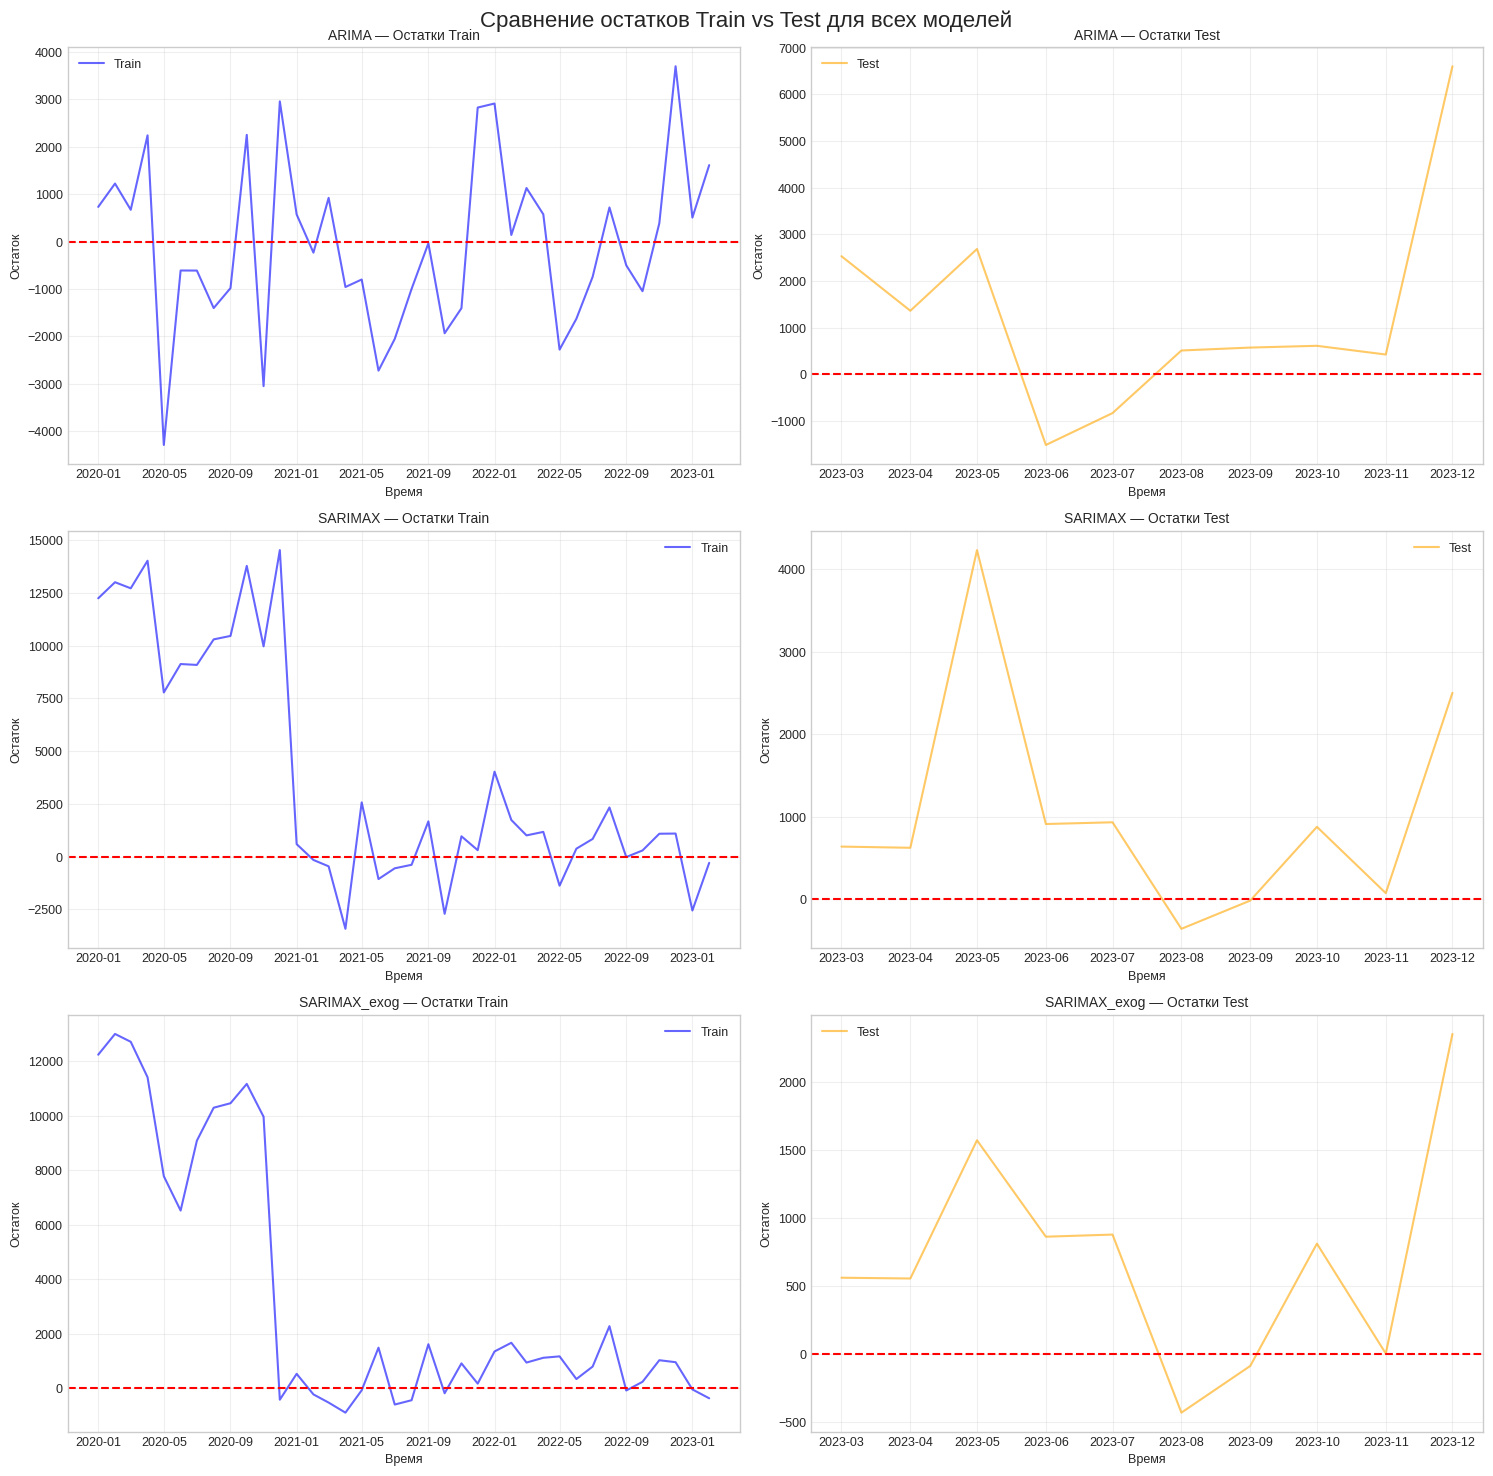

In [ ]:
# -------------------------------------------------------------------------
# 1. ФУНКЦИЯ ДИАГНОСТИКИ (универсальная для ARIMA/SARIMAX)
# -------------------------------------------------------------------------
def run_diagnostics(y_true, y_pred, X=None, dataset_name="Dataset"):

    # Создаем DataFrame для удобства, если есть X
    if X is not None and not X.empty:
        df_diag = pd.concat([y_true, X], axis=1).dropna()
        features = ' + '.join(X.columns)
        formula = f'SalesAmount ~ {features}'
        try:
            ols_model = smf.ols(formula=formula, data=df_diag).fit()
            residuals = ols_model.resid
            fitted_values = ols_model.fittedvalues
        except Exception as e:
            print(f"⚠️ {dataset_name}: ошибка при построении OLS модели: {e}")
            return None
    else:
        # Если X нет (например, ARIMA/SARIMAX без экзогенных)
        residuals = y_true - y_pred
        fitted_values = y_pred

    print(f"\n{'='*20} {dataset_name.upper()} {'='*20}")

    # 1. Breusch-Pagan (только если есть OLS модель)
    if X is not None and not X.empty:
        try:
            bp_test = sm.stats.diagnostic.het_breuschpagan(residuals, ols_model.model.exog)
            bp_pval = bp_test[1]
            print(f"Breusch-Pagan p-value: {bp_pval:.4f} → {'✓' if bp_pval >= 0.05 else '⚠️'}")
        except:
            bp_pval = np.nan
            print(f"Breusch-Pagan p-value: N/A")
    else:
        bp_pval = np.nan
        print(f"Breusch-Pagan p-value: N/A (нет регрессоров)")

    # 2. Jarque-Bera (нормальность остатков)
    try:
        jb_test = sm.stats.jarque_bera(residuals)
        jb_pval = jb_test[1]
        print(f"Jarque-Bera p-value: {jb_pval:.4f} → {'✓' if jb_pval >= 0.05 else '⚠️'}")
    except:
        jb_pval = np.nan
        print(f"Jarque-Bera p-value: N/A")

    # 3. Durbin-Watson (автокорреляция)
    try:
        dw_stat = sm.stats.stattools.durbin_watson(residuals)
        dw_ok = 1.5 < dw_stat < 2.5
        print(f"Durbin-Watson: {dw_stat:.4f} → {'✓' if dw_ok else '⚠️'}")
    except:
        dw_stat = np.nan
        dw_ok = False
        print(f"Durbin-Watson: N/A")

    # 4. R²
    try:
        r2 = r2_score(y_true, y_pred)
        print(f"R²: {r2:.4f}")
    except:
        r2 = np.nan
        print(f"R²: N/A")

    return {
        'bp_pval': bp_pval,
        'jb_pval': jb_pval,
        'dw_stat': dw_stat,
        'r2': r2,
        'residuals': residuals,
        'fitted': fitted_values
    }

# -------------------------------------------------------------------------
# 1. ПОДГОТОВКА ДАННЫХ ДЛЯ DIAGNOSTICS
# -------------------------------------------------------------------------
empty_X_train = pd.DataFrame(index=train.index)
empty_X_test = pd.DataFrame(index=test.index)

# Словарь для хранения результатов всех моделей
diagnostics_results = {}

# -------------------------------------------------------------------------
# 2. ЗАПУСК ДИАГНОСТИКИ (Train и Test)
# -------------------------------------------------------------------------

models_for_diag = {
    "ARIMA": {
        "train_pred": model_arima_train.predict(start=0, end=len(train)-1, typ='levels'),
        "test_pred": forecast_arima_train
    },
    "SARIMAX": {
        "train_pred": model_sarimax_train.predict(start=0, end=len(train)-1, typ='levels'),
        "test_pred": forecast_sarimax_train
    },
    "SARIMAX_exog": {
        "train_pred": model_sarimax_exog_train.predict(start=0, end=len(train)-1, typ='levels', exog=train[['Promotion','HolidayMonth']]),
        "test_pred": forecast_mean_train
    }
}

print("="*60)
print("ДИАГНОСТИКА МОДЕЛЕЙ")
print("="*60)

for model_name, preds in models_for_diag.items():
    print(f"\n--- {model_name.upper()} ---")

    # TRAIN
    print(f"\n[{model_name}] TRAIN")
    train_res = run_diagnostics(
        y_true=train['SalesAmount'],
        y_pred=preds['train_pred'],
        X=empty_X_train,
        dataset_name=f"{model_name} TRAIN"
    )

    # TEST
    print(f"\n[{model_name}] TEST")
    test_res = run_diagnostics(
        y_true=test['SalesAmount'],
        y_pred=preds['test_pred'],
        X=empty_X_test,
        dataset_name=f"{model_name} TEST"
    )

    diagnostics_results[model_name] = {"train": train_res, "test": test_res}

# -------------------------------------------------------------------------
# 3. СРАВНИТЕЛЬНАЯ ТАБЛИЦА (R², Breusch-Pagan, JB, DW)
# -------------------------------------------------------------------------
for model_name, res in diagnostics_results.items():
    train_res = res["train"]
    test_res = res["test"]

    if train_res and test_res:
        print(f"\n{'='*60}")
        print(f"СРАВНЕНИЕ ДИАГНОСТИКИ: {model_name} TRAIN vs TEST")
        print("="*60)
        print(f"{'Тест':<25} | {'Train':<12} | {'Test':<12} | {'Статус':<15}")
        print("-"*60)

        # Breusch-Pagan
        bp_status = "✓ Согласовано" if (train_res['bp_pval']>=0.05) == (test_res['bp_pval']>=0.05) else "⚠️ Расхождение"
        print(f"{'Homoscedasticity (BP)':<25} | {train_res['bp_pval']:<12.4f} | {test_res['bp_pval']:<12.4f} | {bp_status:<15}")

        # Jarque-Bera
        jb_status = "✓ Согласовано" if (train_res['jb_pval']>=0.05) == (test_res['jb_pval']>=0.05) else "⚠️ Расхождение"
        print(f"{'Normality (JB)':<25} | {train_res['jb_pval']:<12.4f} | {test_res['jb_pval']:<12.4f} | {jb_status:<15}")

        # Durbin-Watson
        dw_train_ok = 1.5 < train_res['dw_stat'] < 2.5 if not np.isnan(train_res['dw_stat']) else False
        dw_test_ok = 1.5 < test_res['dw_stat'] < 2.5 if not np.isnan(test_res['dw_stat']) else False
        dw_status = "✓ Согласовано" if dw_train_ok == dw_test_ok else "⚠️ Расхождение"
        print(f"{'Autocorrelation (DW)':<25} | {train_res['dw_stat']:<12.4f} | {test_res['dw_stat']:<12.4f} | {dw_status:<15}")

        # R²
        r2_diff = abs(train_res['r2'] - test_res['r2'])
        r2_status = "✓ Стабильно" if r2_diff < 0.1 else "⚠️ Падение качества"
        print(f"{'R²':<25} | {train_res['r2']:<12.4f} | {test_res['r2']:<12.4f} | {r2_status:<15}")

# -------------------------------------------------------------------------
# 4. ИНТЕРПРЕТАЦИЯ
# -------------------------------------------------------------------------
if train_results and test_results:
    print(f"\n{'='*60}")
    print("ИНТЕРПРЕТАЦИЯ")
    print("="*60)

    # Проверка на переобучение
    if train_results['r2'] > 0.9 and test_results['r2'] < 0.5:
        print("⚠️  ВЫСОКИЙ РИСК ПЕРЕОБУЧЕНИЯ!")
        print("   Модель отлично работает на train, но плохо на test.")
    elif abs(train_results['r2'] - test_results['r2']) < 0.1:
        print("✓ Модель обобщает данные корректно (R² стабилен).")

    # Проверка предпосылок OLS
    if train_results['bp_pval'] < 0.05 or test_results['bp_pval'] < 0.05:
        print("\n⚠️  Обнаружена гетероскедастичность.")

    if train_results['dw_stat'] < 1.5 or test_results['dw_stat'] < 1.5:
        print("\n⚠️  Обнаружена положительная автокорреляция остатков.")

# -------------------------------------------------------------------------
# 5. ВИЗУАЛИЗАЦИЯ (остатки Train/Test для всех моделей)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(len(diagnostics_results), 2, figsize=(15, 5*len(diagnostics_results)))
fig.suptitle('Сравнение остатков Train vs Test для всех моделей', fontsize=16)

for i, (model_name, res) in enumerate(diagnostics_results.items()):
    train_res = res["train"]
    test_res = res["test"]

    # --- Остатки во времени (Train) ---
    axes[i, 0].plot(train_res['residuals'].index, train_res['residuals'].values, alpha=0.6, label='Train', color='blue')
    axes[i, 0].axhline(0, color='red', linestyle='--')
    axes[i, 0].set_title(f"{model_name} — Остатки Train")
    axes[i, 0].set_xlabel('Время')
    axes[i, 0].set_ylabel('Остаток')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    # --- Остатки во времени (Test) ---
    axes[i, 1].plot(test_res['residuals'].index, test_res['residuals'].values, alpha=0.6, color='orange', label='Test')
    axes[i, 1].axhline(0, color='red', linestyle='--')
    axes[i, 1].set_title(f"{model_name} — Остатки Test")
    axes[i, 1].set_xlabel('Время')
    axes[i, 1].set_ylabel('Остаток')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вывод:**

Анализ остатков является важным этапом проверки корректности статистической модели. Остатки должны обладать свойствами белого шума, то есть иметь нулевое математическое ожидание, постоянную дисперсию и отсутствие автокорреляции.

Для оценки данных свойств были применены статистические тесты Breusch–Pagan, Jarque–Bera и Durbin–Watson.

Результаты анализа остатков для модели ARIMA показали следующие значения: p-value теста Jarque–Bera = 0.9490, что свидетельствует о нормальности распределения остатков. Значение статистики Durbin–Watson составило 1.8554, что близко к оптимальному значению 2 и указывает на отсутствие значимой автокорреляции.

Для общей диагностической модели также были получены значения p-value теста Breusch–Pagan = 0.7367 и Jarque–Bera = 0.7730. Это означает, что гипотезы о гомоскедастичности и нормальности остатков не отвергаются.

Таким образом, остатки моделей в целом удовлетворяют ключевым предпосылкам статистического моделирования. Это подтверждает корректность спецификации моделей и надежность полученных оценок параметров.

Однако следует отметить, что статистическая корректность модели не всегда гарантирует высокую точность прогнозирования. Именно поэтому результаты анализа остатков необходимо рассматривать совместно с метриками качества прогноза.

#Итоговый вывод

В ходе исследования была проведена комплексная оценка моделей прогнозирования временного ряда месячных продаж на основе методов ARIMA и SARIMAX. Анализ включал построение моделей, оценку их параметров, сравнение по информационным критериям, анализ метрик качества прогнозирования и диагностику остатков.

Модель ARIMA продемонстрировала умеренные результаты. Она смогла частично описать автокорреляционную структуру временного ряда, однако объяснила лишь около 27% вариации наблюдаемых значений. Это связано с тем, что модель учитывает только внутренние зависимости временного ряда и не включает внешние факторы.

Модель SARIMAX без экзогенных переменных показала наихудшие результаты прогнозирования. Несмотря на учет сезонности, точность прогнозов оказалась крайне низкой, а коэффициент детерминации принял отрицательное значение. Это свидетельствует о недостаточности выбранной спецификации модели.

Наиболее эффективной оказалась модель SARIMAX с экзогенными переменными Promotion и HolidayMonth. Данная модель продемонстрировала наименьшее значение среднеквадратичной ошибки и наибольшее значение коэффициента детерминации (R² = 0.6735). Кроме того, она показала наилучшие значения информационных критериев AIC и BIC среди моделей, построенных на полной выборке.

Полученные результаты подтверждают важность учета внешних факторов при моделировании временных рядов продаж. Маркетинговая активность и календарные эффекты оказывают значительное влияние на динамику спроса, и их включение в модель существенно повышает точность прогнозирования.

Таким образом, по совокупности критериев качества, информационных показателей и интерпретируемости результатов предпочтительной моделью для прогнозирования рассматриваемого временного ряда является модель SARIMAX с экзогенными переменными.